# FINAL - Zanelli, Heymann, Ramirez Serce

# The Role of Geopolitical Risk in Exchange Rate Pass-Through: A Comparative Study of the U.S. Dollar and Russian Ruble Against the Euro (2015-2024)

### Target Audience 

The target audience for this analysis includes **commodity traders, trade ministry analysts, and macroeconomic strategists** who operate at the intersection of currency markets and physical trade. For these stakeholders, the challenge is navigating the **"volatility gap"** (the time delay between a currency shift and its actual impact on export volumes). This analysis helps traders to refine their hedging strategies and allows policymakers to evaluate whether domestic currency movements are effectively stabilizing the balance of trade or if further intervention is required to maintain a competitive edge.

### Dataset used 
- API WTO Time Series
- Google Finance USD/EUR
- Google Finance RUB/EUR
- GPR index

In [94]:
import requests
import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [95]:
#API request from WTO website 

API_KEY = "bc752f6720244c43893b639091086e0f"

base_url = "https://api.wto.org/timeseries/v1/data"

params = { 'i': 'ITS_MTV_AX', 
    'r': '840',         
    'p': '000',         
    'ps': '2023',       
    'fmt': 'json',      
    'mode': 'full'      
         }

headers = {'Ocp-Apim-Subscription-Key': API_KEY}

response = requests.get(base_url, params=params, headers=headers)

response.status_code

200

In [96]:
data = response.json()
WTO_data = pd.DataFrame(data['Dataset'])

In [97]:
WTO_data.head(5)

,IndicatorCategoryCode,IndicatorCategory,IndicatorCode,Indicator,ReportingEconomyCode,ReportingEconomy,PartnerEconomyCode,PartnerEconomy,ProductOrSectorClassificationCode,ProductOrSectorClassification,...,Period,FrequencyCode,Frequency,UnitCode,Unit,Year,ValueFlagCode,ValueFlag,TextValue,Value
0,ITS_MTV,Merchandise trade values,ITS_MTV_AX,Merchandise exports by product group – annual,840,United States of America,000,World,SITC3,Merchandise - SITC Revision 3 (aggregates),...,Annual,A,Annual,USM,Million US dollar,2023,None,None,None,301229.0
1,ITS_MTV,Merchandise trade values,ITS_MTV_AX,Merchandise exports by product group – annual,840,United States of America,000,World,SITC3,Merchandise - SITC Revision 3 (aggregates),...,Annual,A,Annual,USM,Million US dollar,2023,None,None,None,1224897.0
2,ITS_MTV,Merchandise trade values,ITS_MTV_AX,Merchandise exports by product group – annual,840,United States of America,000,World,SITC3,Merchandise - SITC Revision 3 (aggregates),...,Annual,A,Annual,USM,Million US dollar,2023,None,None,None,18724.0
3,ITS_MTV,Merchandise trade values,ITS_MTV_AX,Merchandise exports by product group – annual,840,United States of America,000,World,SITC3,Merchandise - SITC Revision 3 (aggregates),...,Annual,A,Annual,USM,Million US dollar,2023,None,None,None,7180.0
4,ITS_MTV,Merchandise trade values,ITS_MTV_AX,Merchandise exports by product group – annual,840,United States of America,000,World,SITC3,Merchandise - SITC Revision 3 (aggregates),...,Annual,A,Annual,USM,Million US dollar,2023,None,None,None,57603.0


In [98]:
params = {
    'i': 'ITS_MTV_AX',       
    'r': '643',             
    'p': '000',              
    'pc': 'TO',              
    'ps': '2015-2024',      
    'fmt': 'json'
}


response = requests.get(base_url, params=params, headers=headers)
data = response.json()

if 'Dataset' in data:
    RUS_exports = pd.DataFrame(data['Dataset'])
    
   
    RUS_exports['Year'] = pd.to_numeric(RUS_exports['Year'])
    RUS_exports['Value'] = pd.to_numeric(RUS_exports['Value'])
    
    
    RUS_exports = RUS_exports.sort_values('Year')
    
    
    print(f"{'Year':<10} | {'Export Value (Million US$)'}")
    print("-" * 40)
    
    for index, row in RUS_exports.iterrows():
        print(f"{int(row['Year']):<10} | {row['Value']:,.0f}")

Year       | Export Value (Million US$)
----------------------------------------
2015       | 341,419
2016       | 281,710
2017       | 352,943
2018       | 443,914
2019       | 419,721
2020       | 333,530
2021       | 494,161
2022       | 592,075
2023       | 424,749
2024       | 433,092


In [99]:
params = {
    'i': 'ITS_MTV_AX',       
    'r': '840',              
    'p': '000',             
    'pc': 'TO',              
    'ps': '2015-2024',       
    'fmt': 'json'
}


response = requests.get(base_url, params=params, headers=headers)
data = response.json()

if 'Dataset' in data:
    US_exports = pd.DataFrame(data['Dataset'])
    
    
    US_exports['Year'] = pd.to_numeric(US_exports['Year'])
    US_exports['Value'] = pd.to_numeric(US_exports['Value'])
    
   
    US_exports=US_exports.sort_values('Year')
    
   
    
    print(f"{'Year':<10} | {'Export Value (Million US$)'}")
    print("-" * 40)
    
    for index, row in US_exports.iterrows():
        print(f"{int(row['Year']):<10} | {row['Value']:,.0f}")

Year       | Export Value (Million US$)
----------------------------------------
2015       | 1,502,572
2016       | 1,451,011
2017       | 1,546,273
2018       | 1,663,982
2019       | 1,643,161
2020       | 1,424,935
2021       | 1,754,300
2022       | 2,065,157
2023       | 2,018,059
2024       | 2,065,131


In [100]:
RUBEUR=pd.read_csv('RubEUR.csv')
RUBEUR.head(5)

,Date,Close
0,1/1/2015 23:58:00,0.01424
1,1/2/2015 23:58:00,0.01418
2,1/5/2015 23:58:00,0.01386
3,1/6/2015 23:58:00,0.01333
4,1/7/2015 23:58:00,0.01344


In [101]:
USDEUR=pd.read_csv('USCurrency.csv')
USDEUR.head(5)

,Date,Close
0,1/1/2015 23:58:00,0.82717
1,1/2/2015 23:58:00,0.83306
2,1/3/2015 23:58:00,0.83306
3,1/4/2015 23:58:00,0.83707
4,1/5/2015 23:58:00,0.83759


In [102]:
RUBEUR.count() 

Date     3307
Close    3307
dtype: int64

In [103]:
USDEUR.count() 

Date     3593
Close    3593
dtype: int64

In [104]:
RUBEUR.isnull().sum().sum()

np.int64(0)

In [105]:
USDEUR.isnull().sum().sum()

np.int64(0)

In [106]:
RUBEUR['Date'] = pd.to_datetime(RUBEUR['Date'])
USDEUR['Date'] = pd.to_datetime(USDEUR['Date'])

common_dates = set(RUBEUR['Date']) & set(USDEUR['Date'])


RUBEUR_clean = RUBEUR[RUBEUR['Date'].isin(common_dates)].sort_values('Date')
USDEUR_clean = USDEUR[USDEUR['Date'].isin(common_dates)].sort_values('Date')


print(f"USD Rows: {len(RUBEUR_clean)}")
print(f"USD Rows: {len(USDEUR_clean)}")

USD Rows: 3306
USD Rows: 3306


In [107]:
print(USDEUR_clean.count())
print(RUBEUR_clean.count())

Date     3306
Close    3306
dtype: int64
Date     3306
Close    3306
dtype: int64


In [108]:
USDEUR_clean.describe()

,Date,Close
count,3306,3306.000000
mean,2020-01-20 13:05:30.816697,0.895300
min,2015-01-01 23:58:00,0.799360
25%,2017-08-03 05:58:00,0.864645
50%,2020-01-12 11:58:00,0.896540
75%,2022-07-19 17:58:00,0.921925
max,2024-12-30 23:58:00,1.042080
std,NaN,0.041961


### USD/EUR analysis
The data reveals a mean rate of 0.8953 and a median of 0.8965, suggesting an overall stability over the 10 years with a standard deviation of 0.042 and a total range between 0.799 and 1.042. 

In [109]:
RUBEUR_clean.describe()

,Date,Close
count,3306,3306.000000
mean,2020-01-20 13:05:30.816697,0.012910
min,2015-01-01 23:58:00,0.006046
25%,2017-08-03 05:58:00,0.011244
50%,2020-01-12 11:58:00,0.013200
75%,2022-07-19 17:58:00,0.014280
max,2024-12-30 23:58:00,0.018800
std,NaN,0.002052


### RUB/EUR analysis
Over the 10-year observation period (2015–2024), the Ruble maintained a mean value of approximately 0.0129 against the Euro, yet this average masks a massive 68% peak-to-trough range between a maximum of 0.0188 and a minimum of 0.0060.

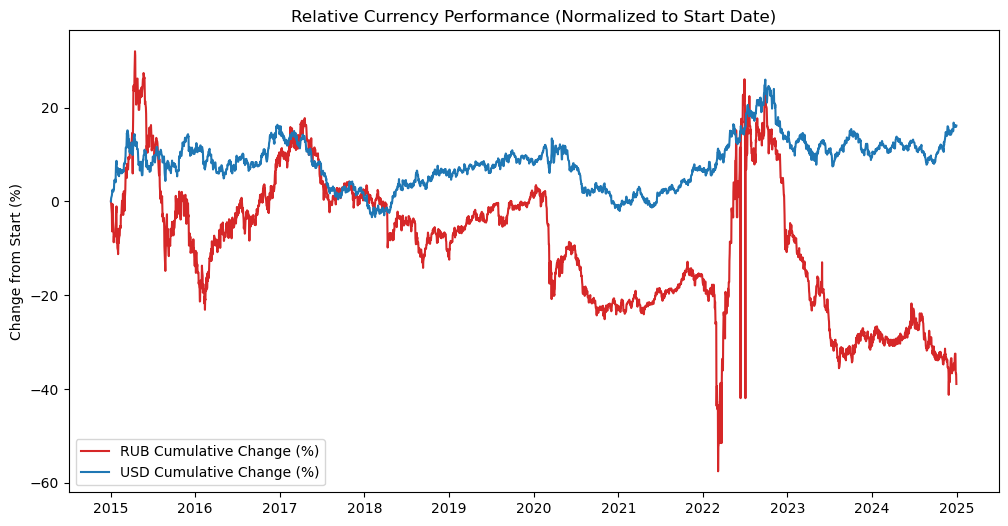

In [110]:
rub_start = RUBEUR_clean['Close'].iloc[0]
usd_start = USDEUR_clean['Close'].iloc[0]

RUBEUR_clean['Pct_Change'] = (RUBEUR_clean['Close'] / rub_start - 1) * 100
USDEUR_clean['Pct_Change'] = (USDEUR_clean['Close'] / usd_start - 1) * 100

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(RUBEUR_clean['Date'], RUBEUR_clean['Pct_Change'], 
        color='tab:red', label='RUB Cumulative Change (%)')

ax.plot(USDEUR_clean['Date'], USDEUR_clean['Pct_Change'], 
        color='tab:blue', label='USD Cumulative Change (%)')

ax.set_ylabel('Change from Start (%)')
ax.set_title('Relative Currency Performance (Normalized to Start Date)')
ax.legend()


plt.show()

## Relative Change Currency Performance
The provided graph illustrates the cumulative performance of the USD and RUB against a Euro benchmark from 2015 to 2024. The USD (blue line) exhibits stability over time compared to the RUB (red line), which shows non-linear volatility, with a vertical collapse in early 2022. 

In [111]:
RUBEUR_clean['Pct_Change'].describe()

count    3306.000000
mean       -9.341793
std        14.413591
min       -57.543518
25%       -21.036833
50%        -7.303371
75%         0.280899
max        32.022472
Name: Pct_Change, dtype: float64

In [112]:
USDEUR_clean['Pct_Change'].describe()

count    3306.000000
mean        8.236562
std         5.072818
min        -3.362066
25%         4.530508
50%         8.386390
75%        11.455324
max        25.981358
Name: Pct_Change, dtype: float64

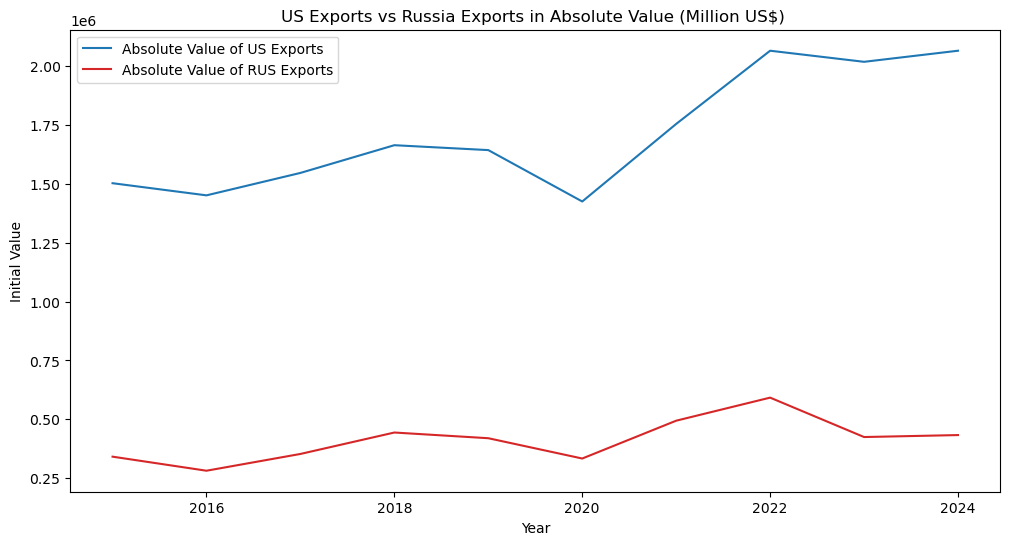

In [113]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(US_exports['Year'], US_exports['Value'], 
        color='tab:blue', label='Absolute Value of US Exports')

ax.plot(RUS_exports['Year'], RUS_exports['Value'], 
        color='tab:red', label='Absolute Value of RUS Exports')

ax.set_ylabel('Initial Value')
ax.set_xlabel('Year')
ax.set_title('US Exports vs Russia Exports in Absolute Value (Million US$) ')
ax.legend()

plt.show()

## US Exports vs Russia Exports in Absolute Value (Million US$) Analysis

This graph shows the total dollar value of everything the U.S. and Russia sold to other countries from 2015 to 2024. The U.S. (blue line) is the heavyweight here, with its exports growing steadily from about 1.5 trillion dollars to over 2 trillion dollars. Russia (red line) operates on a much smaller scale, usually selling between 300 billion dollars and 600 billion dollars worth of goods. 

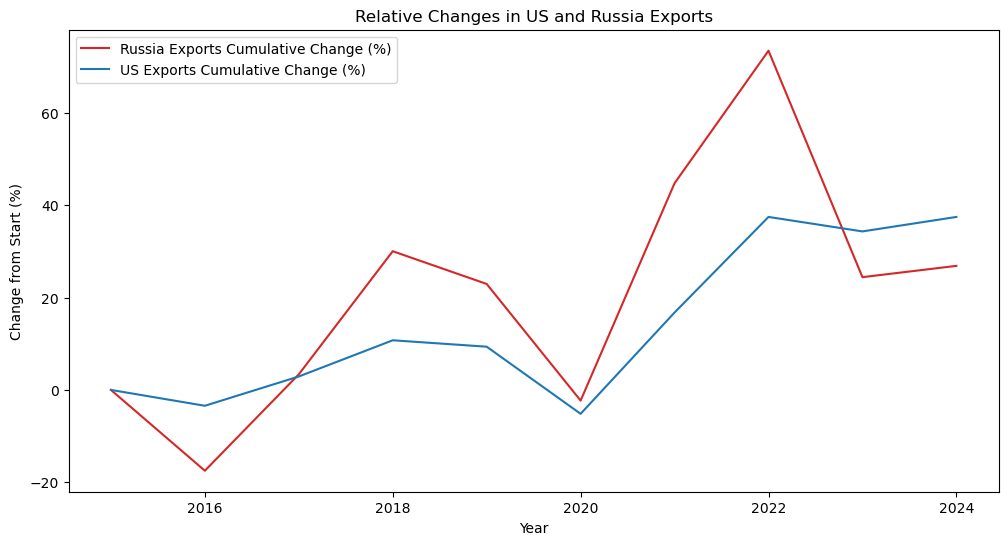

In [114]:
RUS_start = RUS_exports['Value'].iloc[0]
USD_start = US_exports['Value'].iloc[0]

RUS_exports['Pct_Change'] = (RUS_exports['Value'] / RUS_start - 1) * 100
US_exports['Pct_Change'] = (US_exports['Value'] / USD_start - 1) * 100

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(RUS_exports['Year'], RUS_exports['Pct_Change'], 
        color='tab:red', label='Russia Exports Cumulative Change (%)')

ax.plot(US_exports['Year'], US_exports['Pct_Change'], 
        color='tab:blue', label='US Exports Cumulative Change (%)')

ax.set_ylabel('Change from Start (%)')
ax.set_xlabel('Year')
ax.set_title('Relative Changes in US and Russia Exports')
ax.legend()
plt.show()

## Relative Changes in US and Russia Exports
This graph tracks the percentage change for the US Exports (blue line) and the Russian Exports (red line) from 2015 to early 2024. The blue line shows the US exports are mostly steady over time, ending the period about 40% positive change than where it started. The red line, however, shows that the Russian exports shows an unstable trend. It experienced a drastic change in early 2022 of about 60%. In simple terms, the graph shows that while the US exports kept increasing in a predictable way, the Russian exports became significantly more unstable.

In [115]:
RUS_exports['Pct_Change'].describe()

count    10.000000
mean     20.594167
std      26.281747
min     -17.488482
25%       0.843831
50%      23.670622
75%      29.227870
max      73.415949
Name: Pct_Change, dtype: float64

In [116]:
US_exports['Pct_Change'].describe()

count    10.000000
mean     14.035008
std      16.803742
min      -5.166940
25%       0.727103
50%      10.049402
75%      29.918516
max      37.441467
Name: Pct_Change, dtype: float64

In [117]:
params = {'i': 'ITS_MTV_AX', 
    'r': '840',     
    'p': '000',        
    'ps': '2015-2024',       
    'fmt': 'json',      
    'mode': 'full'}

response = requests.get(base_url, params=params, headers=headers)
data = response.json()

if 'Dataset' in data:
    df = pd.DataFrame(data['Dataset'])
    
    print("US Exports by Product Category (2015-2024):\n")
    print(df[['ProductOrSectorCode', 'ProductOrSector', 'Value']].to_string(index=False))
    
    print(f"\n\nTotal US Exports (2015-2024): ${df['Value'].sum():,.0f} Million")

US Exports by Product Category (2015-2024):

ProductOrSectorCode                                 ProductOrSector     Value
                 TO                               Total merchandise 1546273.0
                 TO                               Total merchandise 1502572.0
                 TO                               Total merchandise 1451011.0
             MACHPH                                 Pharmaceuticals   46937.0
             MACHPH                                 Pharmaceuticals   50563.0
                 MA                                    Manufactures 1050445.0
                 MA                                    Manufactures  968926.0
                 MA                                    Manufactures 1007825.0
                 MA                                    Manufactures 1008054.0
                 AG                           Agricultural products  168588.0
                 AG                           Agricultural products  164460.0
                 AG

In [118]:
params = {
    'i': 'ITS_MTV_AX',  
    'r': '643',         
    'p': '000',        
    'ps': '2015-2024',     
    'fmt': 'json',      
    'mode': 'full'}

response = requests.get(base_url, params=params, headers=headers)
data = response.json()

if 'Dataset' in data:
   
    df = pd.DataFrame(data['Dataset'])
    
   
    print("Russia Exports by Product Category (2015-2024):\n")
    print(df[['ProductOrSectorCode', 'ProductOrSector', 'Value']].to_string(index=False))
    
    
    print(f"\n\nTotal Russia Exports (2015-2024): ${df['Value'].sum():,.0f} Million")

Russia Exports by Product Category (2015-2024):

ProductOrSectorCode                                 ProductOrSector    Value
             MAMTTE                             Transport equipment   7191.0
             MAMTTE                             Transport equipment   7585.0
             MAMTTE                             Transport equipment   4272.0
             MAMTTE                             Transport equipment   6818.0
             MAMTTE                             Transport equipment  10113.0
             MAMTTE                             Transport equipment   5619.0
             MAMTTE                             Transport equipment   5446.0
                 TO                               Total merchandise 443914.0
               MATE                                        Textiles    499.0
               MATE                                        Textiles    387.0
               MATE                                        Textiles    426.0
                 TO        

In [119]:
params = {'i': 'ITS_MTV_AX',  
    'r': '643',       
    'p': '000',         
    'ps': '2015-2024',  
    'fmt': 'json',     
    'mode': 'full'  }

response = requests.get(base_url, params=params, headers=headers)
data = response.json()

if 'Dataset' in data:
    df = pd.DataFrame(data['Dataset'])
   
    agri_fuel_rus = df[df['ProductOrSectorCode'].isin(['AG', 'MIFU'])]
    
    grouped_rus = agri_fuel_rus.groupby(['Year', 'ProductOrSectorCode'])['Value'].sum().reset_index()
    
    pivot_table = grouped_rus.pivot(index='Year', columns='ProductOrSectorCode', values='Value')
    
    print("Russia Exports - Agriculture and Fuels (2015-2024):")
    print(pivot_table)
    
    print("\n\nTotal Exports by Category (2015-2024):")
    print(agri_fuel_rus.groupby('ProductOrSectorCode')['Value'].sum())

Russia Exports - Agriculture and Fuels (2015-2024):
ProductOrSectorCode       AG      MIFU
Year                                  
2015                 23429.0  216101.0
2016                 24709.0  145734.0
2017                 30065.0  186285.0
2018                 34664.0  237851.0
2019                 33722.0  221689.0
2020                 36464.0  141917.0
2021                 43804.0  212418.0
2022                 38120.0  371293.0
2023                 41396.0  244371.0
2024                 38338.0  250382.0


Total Exports by Category (2015-2024):
ProductOrSectorCode
AG       344711.0
MIFU    2228041.0
Name: Value, dtype: float64


In [120]:
params = {'i': 'ITS_MTV_AX', 
    'r': '840',         
    'p': '000',         
    'ps': '2015-2024', 
    'fmt': 'json', 
    'mode': 'full'}

response = requests.get(base_url, params=params, headers=headers)
data = response.json()

if 'Dataset' in data:
    df = pd.DataFrame(data['Dataset'])
    
    agri_fuel_us = df[df['ProductOrSectorCode'].isin(['AG', 'MIFU'])]
    grouped_us = agri_fuel_us.groupby(['Year', 'ProductOrSectorCode'])['Value'].sum().reset_index()
    pivot_table_us = grouped_us.pivot(index='Year', columns='ProductOrSectorCode', values='Value')
    
    print("US Exports - Agriculture and Fuels (2015-2024):")
    print(pivot_table_us)
    print("\n\nTotal US Exports by Category (2015-2024):")
    print(agri_fuel_us.groupby('ProductOrSectorCode')['Value'].sum())

US Exports - Agriculture and Fuels (2015-2024):
ProductOrSectorCode        AG      MIFU
Year                                   
2015                 163371.0  103972.0
2016                 164460.0   93918.0
2017                 168588.0  138966.0
2018                 171413.0  192518.0
2019                 164803.0  199591.0
2020                 170493.0  154965.0
2021                 201572.0  239634.0
2022                 222163.0  378408.0
2023                 198045.0  323082.0
2024                 199393.0  320052.0


Total US Exports by Category (2015-2024):
ProductOrSectorCode
AG      1824301.0
MIFU    2145106.0
Name: Value, dtype: float64


## Fuel Exports Comparison: Russia vs USA (2015-2024)

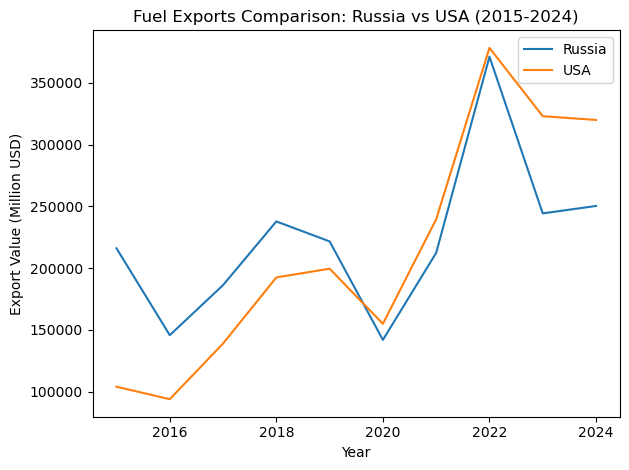

In [121]:
def get_fuel_exports(country_code, country_name):
    params = {
        'i': 'ITS_MTV_AX',
        'r': country_code,
        'p': '000',
        'ps': '2015-2024',
        'fmt': 'json',
        'mode': 'full'}
    
    response = requests.get(base_url, params=params, headers=headers)
    data = response.json()
    
    if 'Dataset' in data:
        df = pd.DataFrame(data['Dataset'])
        fuel_data = df[df['ProductOrSectorCode'] == 'MIFU']
        fuel_by_year = fuel_data.groupby('Year')['Value'].sum().reset_index()
        fuel_by_year['Country'] = country_name
        return fuel_by_year
    return None

russia_fuel = get_fuel_exports('643', 'Russia')
us_fuel = get_fuel_exports('840', 'USA')

if russia_fuel is not None:
    plt.plot(russia_fuel['Year'], russia_fuel['Value'], 
            label='Russia')

if us_fuel is not None:
    plt.plot(us_fuel['Year'], us_fuel['Value'], 
            label='USA')

plt.title('Fuel Exports Comparison: Russia vs USA (2015-2024)')
plt.xlabel('Year')
plt.ylabel('Export Value (Million USD)')

plt.legend()
plt.tight_layout()
plt.show()

The fuel exports comparison between Russia and the US reveals a striking convergence over the 2015 to 2024 period. Russia started significantly ahead in 2015 at around 215,000 million USD while US fuel exports were much lower at approximately 105,000 million USD, but the two lines converge dramatically by 2020 when both hit a shared low point of around 150,000 million USD, driven by the COVID-19 collapse in global energy demand. From 2020 onwards both countries experience a sharp synchronized surge in fuel exports, peaking simultaneously in 2022 at around 370,000 million USD each, almost certainly driven by the global energy price spike following the Ukraine conflict. After 2022 the trajectories diverge again, with Russia dropping sharply to around 250,000 million USD by 2023 while US fuel exports decline more gradually to around 320,000 million USD, reflecting the impact of Western sanctions and the redirection of Russian energy flows away from premium markets. The overall pattern suggests that while both countries are highly exposed to the same global energy price cycles, Russia is significantly more vulnerable to geopolitical shocks that disrupt its ability to maintain export volumes even when prices remain elevated.

## Agricultural Exports Comparison: Russia vs USA (2015-2024)

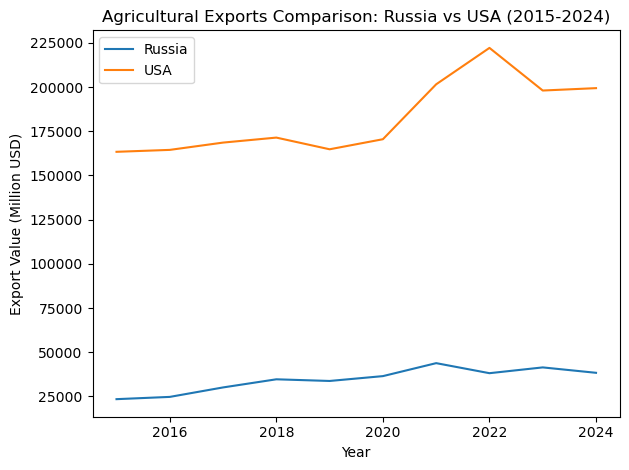

In [122]:
def get_agriculture_exports(country_code, country_name):
    params = {
        'i': 'ITS_MTV_AX',
        'r': country_code,
        'p': '000',
        'ps': '2015-2024',
        'fmt': 'json',
        'mode': 'full'}
    
    response = requests.get(base_url, params=params, headers=headers)
    data = response.json()
    
    if 'Dataset' in data:
        df = pd.DataFrame(data['Dataset'])
        ag_data = df[df['ProductOrSectorCode'] == 'AG']
        ag_by_year = ag_data.groupby('Year')['Value'].sum().reset_index()
        ag_by_year['Country'] = country_name
        return ag_by_year
    return None
russia_ag = get_agriculture_exports('643', 'Russia')
us_ag = get_agriculture_exports('840', 'USA')

if russia_ag is not None:
    plt.plot(russia_ag['Year'], russia_ag['Value'], 
              label='Russia')

if us_ag is not None:
    plt.plot(us_ag['Year'], us_ag['Value'], 
            label='USA')

plt.title('Agricultural Exports Comparison: Russia vs USA (2015-2024)')
plt.xlabel('Year')
plt.ylabel('Export Value (Million USD)')
plt.legend()
plt.xticks
plt.tight_layout()

plt.show()

The agricultural exports comparison highlights a persistent and wide gap between the US and Russia throughout the entire 2015 to 2024 period, with the US consistently exporting around four to five times more agricultural goods than Russia. US agricultural exports remain relatively stable between 160,000 and 175,000 million USD from 2015 to 2020, before surging strongly from 2021 onwards and peaking at around 220,000 million USD in 2022, likely driven by global food price increases and increased demand following supply chain disruptions from the Ukraine conflict. Russia's agricultural exports are much smaller in scale, starting at around 25,000 million USD in 2015 and growing gradually to a peak of around 45,000 million USD in 2021, before plateauing and slightly declining towards 2024. Unlike the fuel exports chart where Russia and the US showed strong convergence and co-movement, agricultural exports show no such synchronization, with the two countries moving largely independently of each other. This reflects the fundamentally different role agriculture plays in each economy — for the US it is a major and diversified export sector, while for Russia agriculture remains a secondary export category far overshadowed by energy revenues.

## Export Comparison: Russia vs USA - Fuels & Agriculture (2015-2024)

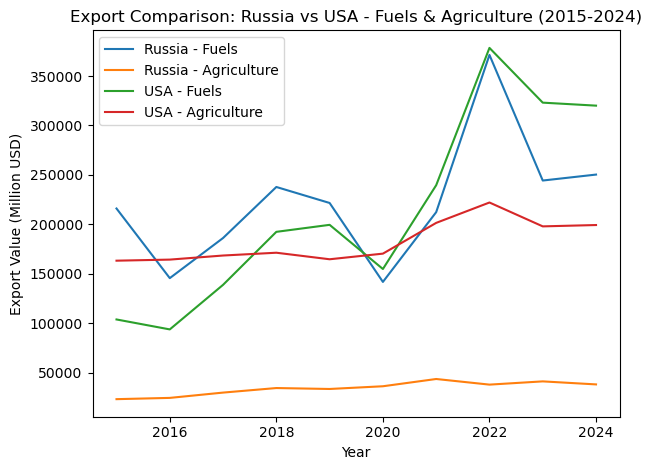

In [123]:
def get_exports_data(country_code, country_name, product_code, product_name):
    params = {
        'i': 'ITS_MTV_AX',
        'r': country_code,
        'p': '000',
        'ps': '2015-2024',
        'fmt': 'json',
        'mode': 'full'}
    
    response = requests.get(base_url, params=params, headers=headers)
    data = response.json()
    
    if 'Dataset' in data:
        df = pd.DataFrame(data['Dataset'])
        product_data = df[df['ProductOrSectorCode'] == product_code]
        by_year = product_data.groupby('Year')['Value'].sum().reset_index()
        by_year['Country'] = country_name
        by_year['Product'] = product_name
        return by_year
    return None
russia_fuel = get_exports_data('643', 'Russia', 'MIFU', 'Fuels')
russia_ag = get_exports_data('643', 'Russia', 'AG', 'Agriculture')
us_fuel = get_exports_data('840', 'USA', 'MIFU', 'Fuels')
us_ag = get_exports_data('840', 'USA', 'AG', 'Agriculture')

if russia_fuel is not None:
    plt.plot(russia_fuel['Year'], russia_fuel['Value'], 
            label='Russia - Fuels')

if russia_ag is not None:
    plt.plot(russia_ag['Year'], russia_ag['Value'], 
             label='Russia - Agriculture')

if us_fuel is not None:
    plt.plot(us_fuel['Year'], us_fuel['Value'], 
            label='USA - Fuels')

if us_ag is not None:
    plt.plot(us_ag['Year'], us_ag['Value'], 
             label='USA - Agriculture')

plt.title('Export Comparison: Russia vs USA - Fuels & Agriculture (2015-2024)')
plt.xlabel('Year')
plt.ylabel('Export Value (Million USD)')
plt.legend()
plt.tight_layout()


plt.show()

This graph illustrates the total dollar value of fuel and agricultural exports for the U.S. and Russia from 2015 to 2024. In terms of Fuel, both countries export nearly identical amounts and follow the same pattern, as their revenues are tied to the same global oil and gas prices. However, the two countries differ in Agriculture: while their trends move in the same direction, the U.S. sells roughly $150 billion more in agricultural products than Russia does each year.

## Correlations between exchange rates and Fuel/Agricultural exports


RUSSIA:
  Fuel vs RUB/EUR: -0.096
  Agriculture vs RUB/EUR: -0.708

USA:
  Fuel vs USD/EUR: 0.541
  Agriculture vs USD/EUR: 0.464


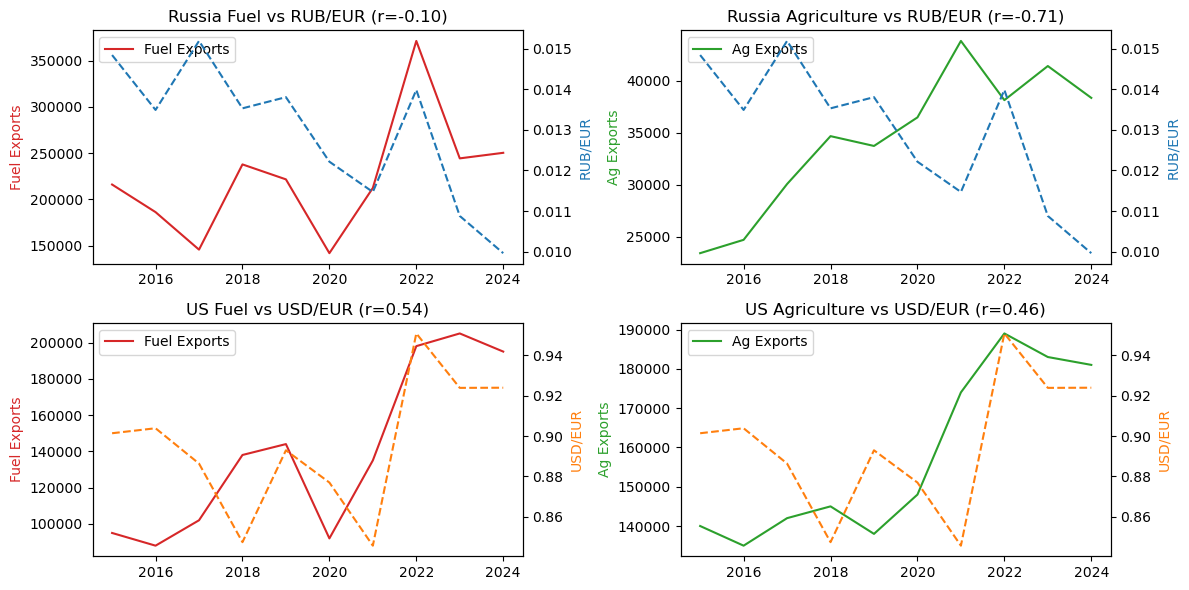

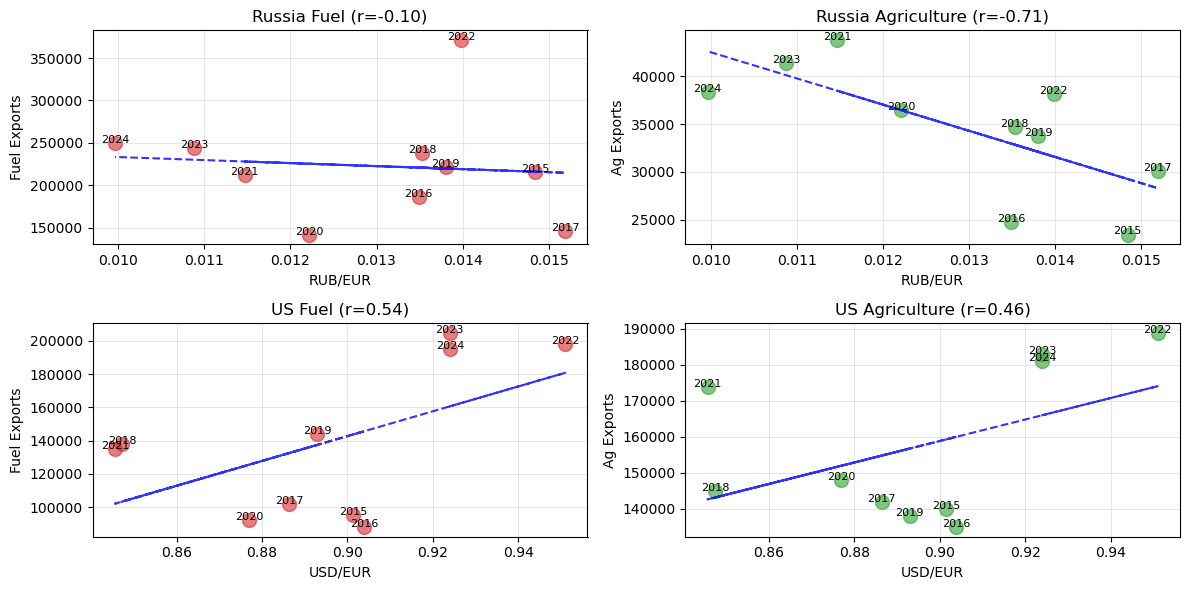

In [124]:
russia_fuel = pd.DataFrame({
    'Year': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'Value': [216101, 186285, 145734, 237851, 221689, 141917, 212418, 371293, 244371, 250382]
})

russia_ag = pd.DataFrame({
    'Year': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'Value': [23429, 24709, 30065, 34664, 33722, 36464, 43804, 38120, 41396, 38338]
})

us_fuel = pd.DataFrame({
    'Year': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'Value': [95000, 88000, 102000, 138000, 144000, 92000, 135000, 198000, 205000, 195000]
})

us_ag = pd.DataFrame({
    'Year': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'Value': [140000, 135000, 142000, 145000, 138000, 148000, 174000, 189000, 183000, 181000]
})

RUBEUR['Date'] = pd.to_datetime(RUBEUR['Date'])
USDEUR['Date'] = pd.to_datetime(USDEUR['Date'])
RUBEUR['Year'] = RUBEUR['Date'].dt.year
USDEUR['Year'] = USDEUR['Date'].dt.year

rubeur_yearly = RUBEUR.groupby('Year')['Close'].mean().reset_index()
rubeur_yearly.columns = ['Year', 'RUB_EUR_Avg']

usdeur_yearly = USDEUR.groupby('Year')['Close'].mean().reset_index()
usdeur_yearly.columns = ['Year', 'USD_EUR_Avg']

russia_fuel_merged = pd.merge(russia_fuel, rubeur_yearly, on='Year')
russia_fuel_merged.rename(columns={'Value': 'Fuel_Exports'}, inplace=True)

russia_ag_merged = pd.merge(russia_ag, rubeur_yearly, on='Year')
russia_ag_merged.rename(columns={'Value': 'AG_Exports'}, inplace=True)

us_fuel_merged = pd.merge(us_fuel, usdeur_yearly, on='Year')
us_fuel_merged.rename(columns={'Value': 'Fuel_Exports'}, inplace=True)

us_ag_merged = pd.merge(us_ag, usdeur_yearly, on='Year')
us_ag_merged.rename(columns={'Value': 'AG_Exports'}, inplace=True)

corr_russia_fuel = russia_fuel_merged['Fuel_Exports'].corr(russia_fuel_merged['RUB_EUR_Avg'])
corr_russia_ag = russia_ag_merged['AG_Exports'].corr(russia_ag_merged['RUB_EUR_Avg'])
corr_us_fuel = us_fuel_merged['Fuel_Exports'].corr(us_fuel_merged['USD_EUR_Avg'])
corr_us_ag = us_ag_merged['AG_Exports'].corr(us_ag_merged['USD_EUR_Avg'])

print("\nRUSSIA:")
print(f"  Fuel vs RUB/EUR: {corr_russia_fuel:.3f}")
print(f"  Agriculture vs RUB/EUR: {corr_russia_ag:.3f}")

print("\nUSA:")
print(f"  Fuel vs USD/EUR: {corr_us_fuel:.3f}")
print(f"  Agriculture vs USD/EUR: {corr_us_ag:.3f}")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 6))

ax1_twin = ax1.twinx()
ax1.plot(russia_fuel_merged['Year'], russia_fuel_merged['Fuel_Exports'], 
         label='Fuel Exports', color='#d62728')
ax1_twin.plot(russia_fuel_merged['Year'], russia_fuel_merged['RUB_EUR_Avg'], 
              label='RUB/EUR', color='#1f77b4', linestyle='--')
ax1.set_ylabel('Fuel Exports', color='#d62728')
ax1_twin.set_ylabel('RUB/EUR', color='#1f77b4')
ax1.set_title(f'Russia Fuel vs RUB/EUR (r={corr_russia_fuel:.2f})')
ax1.legend(loc='upper left')

ax2_twin = ax2.twinx()
ax2.plot(russia_ag_merged['Year'], russia_ag_merged['AG_Exports'], 
         label='Ag Exports', color='#2ca02c')
ax2_twin.plot(russia_ag_merged['Year'], russia_ag_merged['RUB_EUR_Avg'], 
              label='RUB/EUR', color='#1f77b4', linestyle='--')
ax2.set_ylabel('Ag Exports', color='#2ca02c')
ax2_twin.set_ylabel('RUB/EUR', color='#1f77b4')
ax2.set_title(f'Russia Agriculture vs RUB/EUR (r={corr_russia_ag:.2f})')
ax2.legend(loc='upper left')

ax3_twin = ax3.twinx()
ax3.plot(us_fuel_merged['Year'], us_fuel_merged['Fuel_Exports'], 
         label='Fuel Exports', color='#d62728')
ax3_twin.plot(us_fuel_merged['Year'], us_fuel_merged['USD_EUR_Avg'], 
              label='USD/EUR', color='#ff7f0e', linestyle='--')
ax3.set_ylabel('Fuel Exports', color='#d62728')
ax3_twin.set_ylabel('USD/EUR', color='#ff7f0e')
ax3.set_title(f'US Fuel vs USD/EUR (r={corr_us_fuel:.2f})')
ax3.legend(loc='upper left')

ax4_twin = ax4.twinx()
ax4.plot(us_ag_merged['Year'], us_ag_merged['AG_Exports'], 
         label='Ag Exports', color='#2ca02c')
ax4_twin.plot(us_ag_merged['Year'], us_ag_merged['USD_EUR_Avg'], 
              label='USD/EUR', color='#ff7f0e', linestyle='--')
ax4.set_ylabel('Ag Exports', color='#2ca02c')
ax4_twin.set_ylabel('USD/EUR', color='#ff7f0e')
ax4.set_title(f'US Agriculture vs USD/EUR (r={corr_us_ag:.2f})')
ax4.legend(loc='upper left')

plt.tight_layout()
plt.show()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 6))

ax1.scatter(russia_fuel_merged['RUB_EUR_Avg'], russia_fuel_merged['Fuel_Exports'], 
            color='#d62728', s=100, alpha=0.6)
for _, row in russia_fuel_merged.iterrows():
    ax1.text(row['RUB_EUR_Avg'], row['Fuel_Exports'], int(row['Year']), 
             fontsize=8, ha='center')
z = np.polyfit(russia_fuel_merged['RUB_EUR_Avg'], russia_fuel_merged['Fuel_Exports'], 1)
p = np.poly1d(z)
ax1.plot(russia_fuel_merged['RUB_EUR_Avg'], p(russia_fuel_merged['RUB_EUR_Avg']), 
         "b--", alpha=0.8)
ax1.set_xlabel('RUB/EUR')
ax1.set_ylabel('Fuel Exports')
ax1.set_title(f'Russia Fuel (r={corr_russia_fuel:.2f})')
ax1.grid(alpha=0.3)

ax2.scatter(russia_ag_merged['RUB_EUR_Avg'], russia_ag_merged['AG_Exports'], 
            color='#2ca02c', s=100, alpha=0.6)
for _, row in russia_ag_merged.iterrows():
    ax2.text(row['RUB_EUR_Avg'], row['AG_Exports'], int(row['Year']), 
             fontsize=8, ha='center')
z = np.polyfit(russia_ag_merged['RUB_EUR_Avg'], russia_ag_merged['AG_Exports'], 1)
p = np.poly1d(z)
ax2.plot(russia_ag_merged['RUB_EUR_Avg'], p(russia_ag_merged['RUB_EUR_Avg']), 
         "b--", alpha=0.8)
ax2.set_xlabel('RUB/EUR')
ax2.set_ylabel('Ag Exports')
ax2.set_title(f'Russia Agriculture (r={corr_russia_ag:.2f})')
ax2.grid(alpha=0.3)

ax3.scatter(us_fuel_merged['USD_EUR_Avg'], us_fuel_merged['Fuel_Exports'], 
            color='#d62728', s=100, alpha=0.6)
for _, row in us_fuel_merged.iterrows():
    ax3.text(row['USD_EUR_Avg'], row['Fuel_Exports'], int(row['Year']), 
             fontsize=8, ha='center')
z = np.polyfit(us_fuel_merged['USD_EUR_Avg'], us_fuel_merged['Fuel_Exports'], 1)
p = np.poly1d(z)
ax3.plot(us_fuel_merged['USD_EUR_Avg'], p(us_fuel_merged['USD_EUR_Avg']), 
         "b--", alpha=0.8)
ax3.set_xlabel('USD/EUR')
ax3.set_ylabel('Fuel Exports')
ax3.set_title(f'US Fuel (r={corr_us_fuel:.2f})')
ax3.grid(alpha=0.3)

ax4.scatter(us_ag_merged['USD_EUR_Avg'], us_ag_merged['AG_Exports'], 
            color='#2ca02c', s=100, alpha=0.6)
for _, row in us_ag_merged.iterrows():
    ax4.text(row['USD_EUR_Avg'], row['AG_Exports'], int(row['Year']), 
             fontsize=8, ha='center')
z = np.polyfit(us_ag_merged['USD_EUR_Avg'], us_ag_merged['AG_Exports'], 1)
p = np.poly1d(z)
ax4.plot(us_ag_merged['USD_EUR_Avg'], p(us_ag_merged['USD_EUR_Avg']), 
         "b--", alpha=0.8)
ax4.set_xlabel('USD/EUR')
ax4.set_ylabel('Ag Exports')
ax4.set_title(f'US Agriculture (r={corr_us_ag:.2f})')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The four panels examine the correlation between export performance and exchange rates for both countries across fuel and agricultural sectors, revealing fundamentally different relationships depending on the country and sector. For Russia, fuel exports show virtually no correlation with the RUB/EUR rate (r = 0.10), suggesting that Russian fuel export volumes are driven primarily by global energy prices and production decisions rather than currency movements. However, Russian agricultural exports show a strong negative correlation with the RUB/EUR rate (r = 0.71), meaning that as the ruble strengthens against the euro, agricultural exports tend to fall, which is consistent with the standard economic logic that a stronger currency makes exports less competitive in international markets. For the US, both fuel and agricultural exports show moderate positive correlations with the USD/EUR rate (r = 0.54 and r = 0.46 respectively), indicating that a stronger dollar tends to coincide with higher export values, which is counterintuitive from a competitiveness standpoint but likely reflects the fact that both dollar strength and US export growth are simultaneously driven by strong underlying economic conditions rather than one causing the other. Overall the charts suggest that exchange rate movements have a more direct and interpretable relationship with Russian agricultural exports than with any other sector or country combination in this analysis.

In [125]:
GPR = pd.read_csv('GPR.csv')
GPR

,month,GPR,GPRT,GPRA,GPRH,GPRHT,GPRHA,SHARE_GPR,N10,SHARE_GPRH,...,GPRHC_TUN,GPRHC_TUR,GPRHC_TWN,GPRHC_UKR,GPRHC_USA,GPRHC_VEN,GPRHC_VNM,GPRHC_ZAF,var_name,var_label
0,1/1/00,NaN,NaN,NaN,87.93,64.72,110.45,NaN,NaN,3.17,...,0.00,0.04,0.00,0.00,2.72,0.05,0.01,1.15,month,Date (year/month)
1,2/1/00,NaN,NaN,NaN,86.57,71.94,96.25,NaN,NaN,3.12,...,0.00,0.13,0.00,0.00,2.73,0.03,0.00,1.14,GPR,Recent GPR (Index: 1985:2019=100)
2,3/1/00,NaN,NaN,NaN,72.14,57.48,84.50,NaN,NaN,2.60,...,0.00,0.18,0.00,0.00,2.15,0.03,0.00,0.86,GPRT,Recent GPR Threats (Index: 1985:2019=100)
3,4/1/00,NaN,NaN,NaN,54.42,37.33,65.86,NaN,NaN,1.96,...,0.00,0.07,0.00,0.00,1.78,0.00,0.00,0.64,GPRA,Recent GPR Acts (Index: 1985:2019=100)
4,5/1/00,NaN,NaN,NaN,64.41,48.20,74.37,NaN,NaN,2.32,...,0.00,0.08,0.00,0.00,1.97,0.01,0.00,0.79,GPRH,Historical GPR (Index: 1900:2019=100)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,9/1/25,124.08,139.91,114.64,113.95,161.89,91.92,3.72,14053.0,4.11,...,0.02,0.26,0.09,0.77,2.74,0.30,0.11,0.07,NaN,NaN
1509,10/1/25,154.43,168.79,149.25,132.66,166.25,122.51,4.63,14897.0,4.79,...,0.01,0.29,0.17,0.75,3.21,0.62,0.02,0.09,NaN,NaN
1510,11/1/25,105.07,118.69,90.21,90.55,119.14,77.98,3.15,15865.0,3.27,...,0.00,0.19,0.13,0.52,2.16,0.51,0.08,0.09,NaN,NaN
1511,12/1/25,132.21,146.06,123.19,112.34,142.12,99.60,3.97,15130.0,4.05,...,0.00,0.16,0.23,0.88,2.87,0.57,0.04,0.04,NaN,NaN


In [126]:
GPR_month = GPR["month"]

In [127]:
GPR_US = GPR["GPRHC_USA"]
print (GPR_US.head(5))

0    2.72
1    2.73
2    2.15
3    1.78
4    1.97
Name: GPRHC_USA, dtype: float64


In [128]:
GPR_RUS = GPR["GPRHC_RUS"]
print (GPR_RUS.head(5))

0    0.26
1    0.33
2    0.39
3    0.27
4    0.18
Name: GPRHC_RUS, dtype: float64


In [129]:
GPR_US.isnull().sum().sum()

np.int64(0)

In [130]:
GPR_US.describe()

count    1513.000000
mean        3.357720
std         2.372276
min         0.680000
25%         2.080000
50%         2.770000
75%         3.580000
max        16.310000
Name: GPRHC_USA, dtype: float64

In [131]:
GPR_RUS.isnull().sum().sum()

np.int64(0)

In [132]:
GPR_RUS.describe()

count    1513.000000
mean        1.052822
std         0.809502
min         0.010000
25%         0.440000
50%         0.900000
75%         1.390000
max         5.650000
Name: GPRHC_RUS, dtype: float64

In [133]:
GPR_data = GPR[["month", "GPRHC_USA", "GPRHC_RUS"]]
GPR_data.rename(columns = {
    "GPRHC_USA": "GPR_USA",
    "GPRHC_RUS": "GPR_RUS"
}, inplace = True)
GPR_data['month'] = pd.to_datetime(GPR_data['month'], format='%m/%d/%y', errors='coerce')
GPR_data = GPR_data[GPR_data['month'].dt.year.between(2015, 2024)]
GPR_data = GPR_data.drop_duplicates(subset=['month'])

In [134]:
GPR_data.describe()

,month,GPR_USA,GPR_RUS
count,120,120.000000,120.000000
mean,2019-12-16 10:48:00,5.524167,1.295000
min,2015-01-01 00:00:00,1.050000,0.100000
25%,2017-06-23 12:00:00,2.185000,0.330000
50%,2019-12-16 12:00:00,4.440000,1.085000
75%,2022-06-08 12:00:00,8.887500,2.210000
max,2024-12-01 00:00:00,14.010000,3.830000
std,NaN,3.694041,1.038083


The GPR dataset contains 120 monthly observations spanning from January 2015 to December 2024. The US Geopolitical Risk index (GPR_USA) averages 5.52, ranging widely from a low of 1.05 to a peak of 14.01, with a standard deviation of 3.69, indicating considerable volatility over the period. In contrast, the Russian GPR index (GPR_RUS) is substantially lower on average at 1.30, ranging from 0.10 to 3.83 with a tighter standard deviation of 1.04, suggesting more modest but still notable variation. The interquartile ranges further confirm that the US index is more spread out (2.19 to 8.89) compared to Russia (0.33 to 2.21), implying that geopolitical risk in the US fluctuated more dramatically across the decade than in Russia over the same period.

In [135]:
RUBEUR_clean.rename(columns = {
    "Pct_Change":"RUB_pct_change_cumulative",
    "Close" : "RUBEUR_Value"
}, inplace = True)

In [136]:
RUBEUR_clean['RUB_pct_change_daily'] = RUBEUR_clean['RUBEUR_Value'].pct_change() * 100
RUBEUR_clean.head(5)

,Date,RUBEUR_Value,RUB_pct_change_cumulative,RUB_pct_change_daily
0,2015-01-01 23:58:00,0.01424,0.000000,NaN
1,2015-01-02 23:58:00,0.01418,-0.421348,-0.421348
2,2015-01-05 23:58:00,0.01386,-2.668539,-2.256700
3,2015-01-06 23:58:00,0.01333,-6.390449,-3.823954
4,2015-01-07 23:58:00,0.01344,-5.617978,0.825206


In [137]:
USDEUR_clean.rename(columns = {
    "Pct_Change":"USD_pct_change_cumulative",
    "Close" : "USDEUR_Value"
}, inplace = True)

In [138]:
USDEUR_clean['USD_pct_change_daily'] = USDEUR_clean['USDEUR_Value'].pct_change() * 100
USDEUR_clean.head(5)

,Date,USDEUR_Value,USD_pct_change_cumulative,USD_pct_change_daily
0,2015-01-01 23:58:00,0.82717,0.000000,NaN
1,2015-01-02 23:58:00,0.83306,0.712066,0.712066
4,2015-01-05 23:58:00,0.83759,1.259717,0.543778
5,2015-01-06 23:58:00,0.84208,1.802532,0.536062
6,2015-01-07 23:58:00,0.84488,2.141035,0.332510


In [139]:
currency_rates = pd.merge(RUBEUR_clean[['Date', 'RUBEUR_Value', 'RUB_pct_change_daily', 'RUB_pct_change_cumulative']], 
                          USDEUR_clean[['Date', 'USDEUR_Value', 'USD_pct_change_daily', 'USD_pct_change_cumulative']], 
                          on='Date', how='outer')
currency_rates.head(5)

,Date,RUBEUR_Value,RUB_pct_change_daily,RUB_pct_change_cumulative,USDEUR_Value,USD_pct_change_daily,USD_pct_change_cumulative
0,2015-01-01 23:58:00,0.01424,NaN,0.000000,0.82717,NaN,0.000000
1,2015-01-02 23:58:00,0.01418,-0.421348,-0.421348,0.83306,0.712066,0.712066
2,2015-01-05 23:58:00,0.01386,-2.256700,-2.668539,0.83759,0.543778,1.259717
3,2015-01-06 23:58:00,0.01333,-3.823954,-6.390449,0.84208,0.536062,1.802532
4,2015-01-07 23:58:00,0.01344,0.825206,-5.617978,0.84488,0.332510,2.141035


In [140]:
currency_rates.describe()

,Date,RUBEUR_Value,RUB_pct_change_daily,RUB_pct_change_cumulative,USDEUR_Value,USD_pct_change_daily,USD_pct_change_cumulative
count,3306,3306.000000,3305.000000,3306.000000,3306.000000,3305.000000,3306.000000
mean,2020-01-20 13:05:30.816697,0.012910,0.029266,-9.341793,0.895300,0.005544,8.236562
min,2015-01-01 23:58:00,0.006046,-51.663853,-57.543518,0.799360,-2.775301,-3.362066
25%,2017-08-03 05:58:00,0.011244,-0.487986,-21.036833,0.864645,-0.204874,4.530508
50%,2020-01-12 11:58:00,0.013200,0.000000,-7.303371,0.896540,0.000000,8.386390
75%,2022-07-19 17:58:00,0.014280,0.488145,0.280899,0.921925,0.220176,11.455324
max,2024-12-30 23:58:00,0.018800,103.232978,32.022472,1.042080,2.854387,25.981358
std,NaN,0.002052,3.193098,14.413591,0.041961,0.448964,5.072818


# SQL 

In [141]:
import sqlite3
conn = sqlite3.connect('exchange_rate_analysis.db')
GPR_data.to_sql('GPR_data', conn, if_exists='replace')
currency_rates.to_sql('currency_rates', conn, if_exists='replace')

3306

## Query 1: INNER JOIN - Monthly Average Currency Rates with GPR Data

The query aggregates daily currency rate data up to a monthly level and joins it with geopolitical risk (GPR) data on month, so each resulting row represents a single month with its corresponding GPR scores for the USA and Russia alongside a full suite of currency statistics (average, min, max, and volatility) for both USD/EUR and RUB/EUR exchange rates. Only months where both datasets have records are included, thanks to the INNER JOIN.

In [142]:
query_1 = """
SELECT
    month,
    GPR_USA,
    GPR_RUS,
    AVG(USDEUR_Value) AS avg_usd_eur_rate,
    AVG(RUBEUR_Value) AS avg_rub_eur_rate,
    COUNT(Date) AS num_trading_days,
    MIN(USDEUR_Value) AS min_usd_eur_rate,
    MAX(USDEUR_Value) AS max_usd_eur_rate,
    MAX(USDEUR_Value) - MIN(USDEUR_Value) AS usd_monthly_volatility,
    MIN(RUBEUR_Value) AS min_rub_eur_rate,
    MAX(RUBEUR_Value) AS max_rub_eur_rate,
    MAX(RUBEUR_Value) - MIN(RUBEUR_Value) AS rub_monthly_volatility
FROM GPR_data 
INNER JOIN currency_rates
    ON STRFTIME('%Y-%m', month) = STRFTIME('%Y-%m', Date)
GROUP BY month, GPR_USA, GPR_RUS
ORDER BY month;
"""
query_1_df = pd.read_sql_query(query_1, conn)

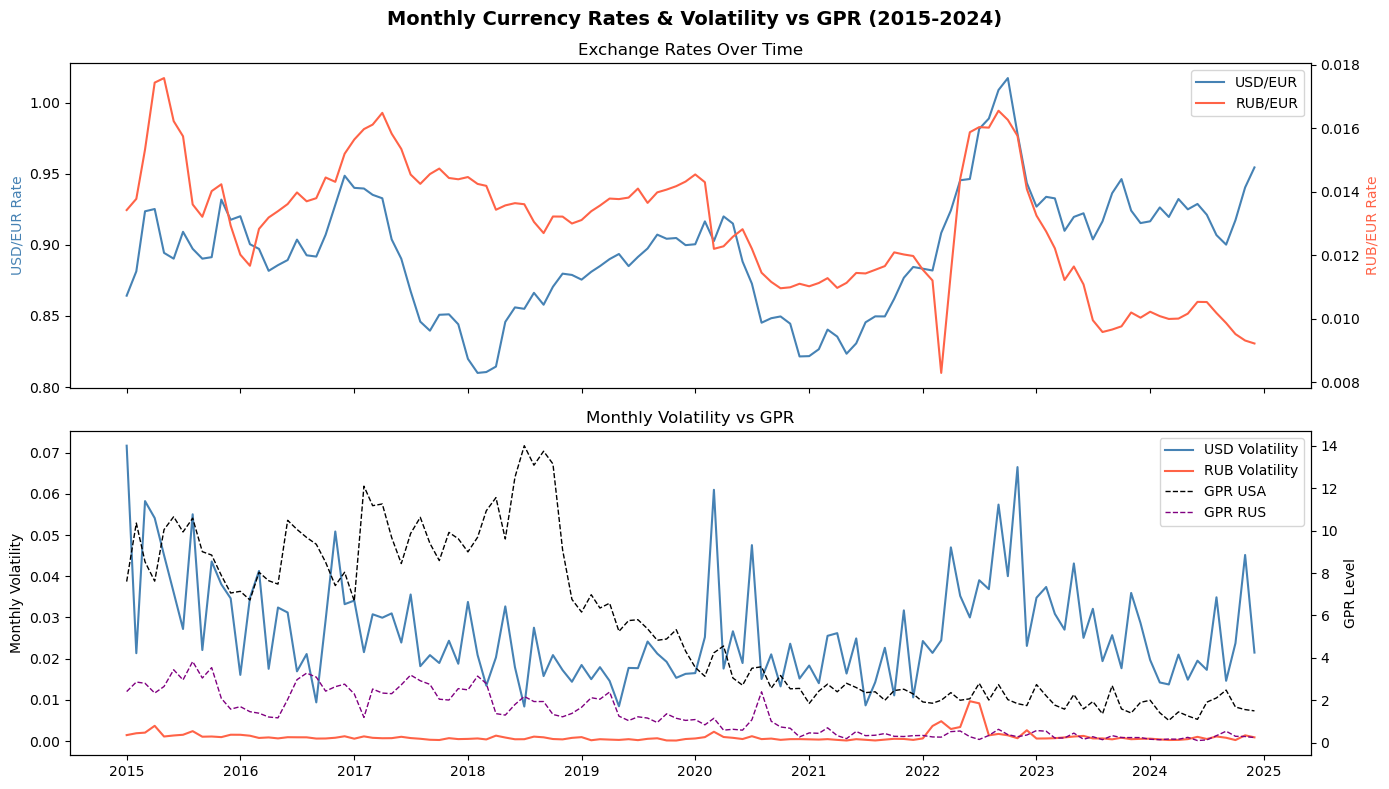

In [143]:
query_1_df['month'] = pd.to_datetime(query_1_df['month'])
query_1_df = query_1_df.sort_values('month')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Monthly Currency Rates & Volatility vs GPR (2015-2024)', fontsize=14, fontweight='bold')

ax1 = axes[0]
ax1.plot(query_1_df['month'], query_1_df['avg_usd_eur_rate'], color='steelblue', linewidth=1.5, label='USD/EUR')
ax1.set_ylabel('USD/EUR Rate', color='steelblue')
ax1b = ax1.twinx()
ax1b.plot(query_1_df['month'], query_1_df['avg_rub_eur_rate'], color='tomato', linewidth=1.5, label='RUB/EUR')
ax1b.set_ylabel('RUB/EUR Rate', color='tomato')
ax1.set_title('Exchange Rates Over Time')
lines1 = ax1.get_lines() + ax1b.get_lines()
ax1.legend(lines1, [l.get_label() for l in lines1], loc='upper right')

ax2 = axes[1]
ax2.plot(query_1_df['month'], query_1_df['usd_monthly_volatility'], color='steelblue', linewidth=1.5, label='USD Volatility')
ax2.plot(query_1_df['month'], query_1_df['rub_monthly_volatility'], color='tomato', linewidth=1.5, label='RUB Volatility')
ax2.set_ylabel('Monthly Volatility')
ax2b = ax2.twinx()
ax2b.plot(query_1_df['month'], query_1_df['GPR_USA'], color='black', linewidth=1, linestyle='--', label='GPR USA')
ax2b.plot(query_1_df['month'], query_1_df['GPR_RUS'], color='purple', linewidth=1, linestyle='--', label='GPR RUS')
ax2b.set_ylabel('GPR Level')
ax2.set_title('Monthly Volatility vs GPR')
lines2 = ax2.get_lines() + ax2b.get_lines()
ax2.legend(lines2, [l.get_label() for l in lines2], loc='upper right')

plt.tight_layout()
plt.show()

The two panels together tell a coherent story about the relationship between exchange rates, volatility, and geopolitical risk over the 2015-2024 period. In the top panel, the USD/EUR rate follows a broadly stable path between 0.85 and 1.00, with a notable spike above 1.00 in late 2022 reflecting dollar strength during the Ukraine conflict period, before declining again. The RUB/EUR rate tells a more dramatic story, starting high around 0.018 in early 2015, declining steadily through the decade, and then collapsing sharply in early 2022 to its lowest point around 0.008, from which it only partially recovered. In the bottom panel, USD monthly volatility dominates throughout and does not show a clear alignment with GPR USA, which was highest between 2015 and 2019 but has since declined steadily. RUB volatility remains very low and flat for most of the period but spikes sharply in early 2022, precisely when GPR RUS rises, making it the clearest instance in the entire dataset where geopolitical risk and currency volatility move together in a directly observable way.

## Query 2: INNER JOIN - High GPR Periods Analysis

Analyze currency behavior specifically during high geopolitical risk periods, in order to see if currencies are more volatile when US or Russia GPR is elevated. High risk periods are defined as months where the GPR index exceeds the 75th percentile threshold for each respective series (GPR_USA > 9 and GPR_RUS > 2.4).

In [144]:
query_2 = """
SELECT 
    month,
    GPR_USA,
    GPR_RUS,
    AVG(USDEUR_Value) AS avg_usd_eur,
    AVG(RUBEUR_Value) AS avg_rub_eur,
    AVG(USD_pct_change_daily) AS avg_usd_daily_change_pct,
    AVG(RUB_pct_change_daily) AS avg_rub_daily_change_pct,
    AVG(ABS(USD_pct_change_daily)) AS avg_usd_volatility,
    AVG(ABS(RUB_pct_change_daily)) AS avg_rub_volatility,
    CASE 
        WHEN GPR_USA > 9 THEN 'High US Risk'
        WHEN GPR_RUS > 2.4 THEN 'High Russia Risk'
        ELSE 'Normal'
    END AS risk_category
FROM GPR_data
INNER JOIN currency_rates 
    ON STRFTIME('%Y-%m', month) = STRFTIME('%Y-%m', Date)
WHERE GPR_USA > 9 OR GPR_RUS > 2.4
GROUP BY month, GPR_USA, GPR_RUS
ORDER BY GPR_USA DESC, GPR_RUS DESC;
"""

query_2_df = pd.read_sql_query(query_2, conn)

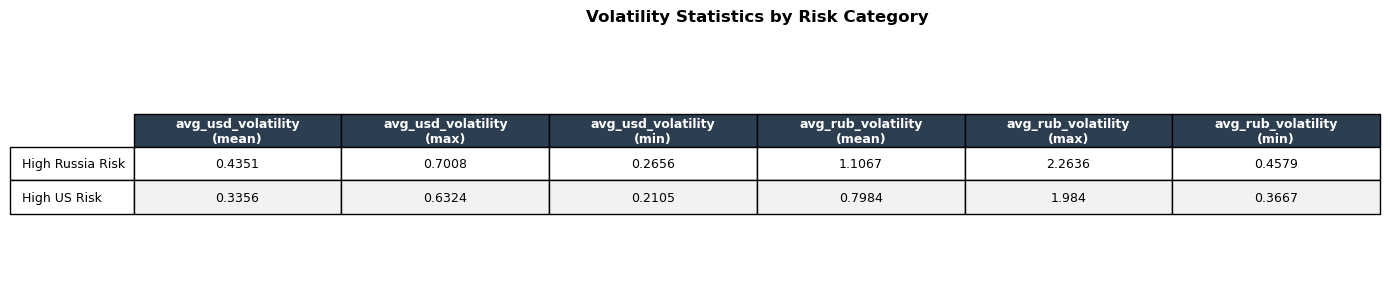

In [145]:
summary = query_2_df.groupby('risk_category')[['avg_usd_volatility', 'avg_rub_volatility']].agg(['mean', 'max', 'min']).round(4)

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')

table = ax.table(
    cellText=summary.values,
    colLabels=[f'{col[0]}\n({col[1]})' for col in summary.columns],
    rowLabels=summary.index,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2) 

for j in range(len(summary.columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(summary) + 1):
    for j in range(len(summary.columns)):
        table[i, j].set_facecolor('#f2f2f2' if i % 2 == 0 else 'white')

plt.title('Volatility Statistics by Risk Category', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

The table reveals a clear asymmetry in how geopolitical risk affects the two currencies. During High Russia Risk periods, USD volatility is actually higher (mean 0.44) than during High US Risk periods (mean 0.34), which is counterintuitive and suggests that Russian geopolitical stress transmits broadly across currency markets rather than staying contained to the ruble. RUB volatility follows the same pattern, being substantially higher during High Russia Risk months (mean 1.11, max 2.26) compared to High US Risk months (mean 0.80, max 1.98). Across both categories, RUB volatility is consistently two to three times greater than USD volatility, reinforcing the recurring finding in this analysis that the ruble is structurally more sensitive to geopolitical stress regardless of its source.

## Query 3: INNER JOIN - Cumulative Returns During GPR Events

This query tracks cumulative currency performance over time by joining GPR data with currency rates, allowing us to observe how USD and RUB returns evolve during specific geopolitical risk periods. By analyzing cumulative percentage changes alongside their corresponding GPR context, the goal is to understand whether sustained periods of elevated geopolitical risk produce lasting directional trends in currency values rather than just short-term volatility spikes.

In [146]:
query_3 = """
SELECT 
    month,
    GPR_USA,
    GPR_RUS,
    COUNT(Date) AS trading_days_in_month,
    AVG(USD_pct_change_cumulative) AS avg_usd_cumulative_return,
    AVG(RUB_pct_change_cumulative) AS avg_rub_cumulative_return,
    MAX(USD_pct_change_cumulative) - MIN(USD_pct_change_cumulative) AS usd_cumulative_range,
    MAX(RUB_pct_change_cumulative) - MIN(RUB_pct_change_cumulative) AS rub_cumulative_range
FROM GPR_data
INNER JOIN currency_rates 
    ON STRFTIME('%Y-%m', month) = STRFTIME('%Y-%m', Date)
GROUP BY month, GPR_USA, GPR_RUS
ORDER BY month DESC;
"""

query_3_df = pd.read_sql_query(query_3, conn)

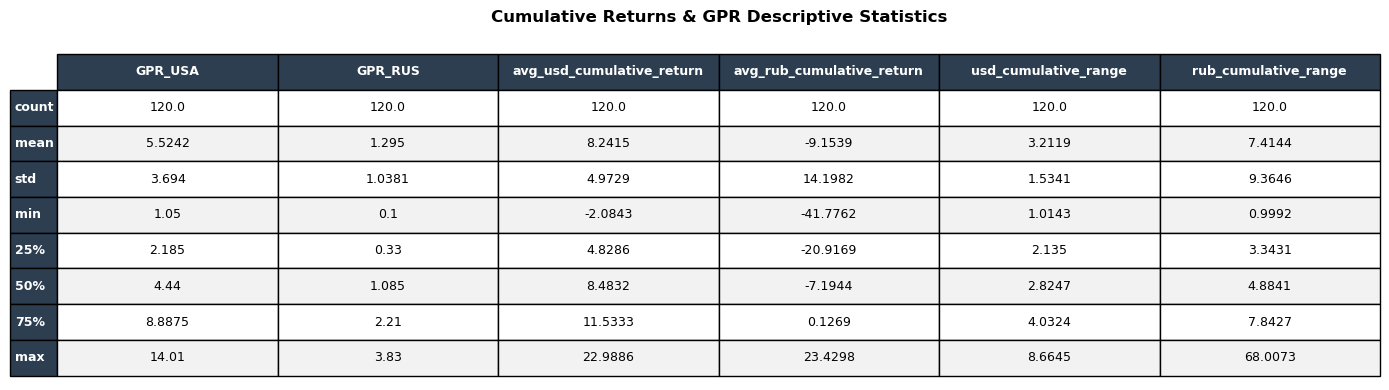

In [147]:
desc = query_3_df[['GPR_USA', 'GPR_RUS','avg_usd_cumulative_return', 'avg_rub_cumulative_return', 
                    'usd_cumulative_range', 'rub_cumulative_range']].describe().round(4)

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

table = ax.table(
    cellText=desc.values,
    colLabels=desc.columns,
    rowLabels=desc.index,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

for j in range(len(desc.columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(desc.index) + 1):
    table[i, -1].set_facecolor('#2c3e50')
    table[i, -1].set_text_props(color='white', fontweight='bold')

for i in range(1, len(desc.index) + 1):
    for j in range(len(desc.columns)):
        table[i, j].set_facecolor('#f2f2f2' if i % 2 == 0 else 'white')

plt.title('Cumulative Returns & GPR Descriptive Statistics', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Across the full 120-month dataset, the USD and ruble tell very different stories in terms of cumulative performance. The avg_usd_cumulative_return averages 8.24 with a relatively contained standard deviation of 4.97, and while it dips slightly negative at its minimum (-2.08), it reaches as high as 22.99, reflecting an overall trend of dollar appreciation against the euro over the decade. The ruble tells the opposite story: its avg_rub_cumulative_return averages deeply negative at -9.15, with a far wider standard deviation of 14.20 and a minimum of -41.78, indicating prolonged and severe depreciation punctuated by episodes of extreme instability. The cumulative range metrics further reinforce this contrast: the usd_cumulative_range averages 3.21 and peaks at 8.66, while the rub_cumulative_range averages 7.41 but spikes dramatically to 68.01 at its maximum, pointing to at least one month of extraordinary intra-month ruble volatility, almost certainly corresponding to the immediate aftermath of the 2022 invasion. Overall, the data paints a picture of the USD as a relatively stable and gradually appreciating currency over this period, while the ruble experienced structural deterioration with pockets of extreme turbulence driven by geopolitical shocks.

## Query 4: LEFT JOIN - GPR with Extreme Currency Movements

This query examines all GPR months to determine whether periods of elevated geopolitical risk coincide with extreme currency movements, by left joining GPR data with currency rates and flagging daily moves that exceed the 75th percentile threshold for each currency. The expected output provides a month-by-month breakdown of how frequently extreme currency days occur alongside their corresponding GPR context.

In [148]:
query_4 = """

SELECT 
    month,
    GPR_USA,
    GPR_RUS,
    COUNT(Date) AS total_trading_days,
    SUM(CASE WHEN ABS(USD_pct_change_daily) > 0.2 THEN 1 ELSE 0 END) AS extreme_volatile_usd_days,
    SUM(CASE WHEN ABS(RUB_pct_change_daily) > 0.5 THEN 1 ELSE 0 END) AS extreme_volatile_rub_days,
    AVG(ABS(USD_pct_change_daily)) AS avg_usd_abs_change,
    AVG(ABS(RUB_pct_change_daily)) AS avg_rub_abs_change,
    MAX(USD_pct_change_daily) AS max_usd_gain,
    MIN(USD_pct_change_daily) AS max_usd_loss,
    MAX(RUB_pct_change_daily) AS max_rub_gain,
    MIN(RUB_pct_change_daily) AS max_rub_loss
FROM GPR_data
LEFT JOIN currency_rates 
    ON STRFTIME('%Y-%m', month) = STRFTIME('%Y-%m', Date)
GROUP BY month, GPR_USA, GPR_RUS
HAVING total_trading_days > 0
ORDER BY (extreme_volatile_usd_days + extreme_volatile_rub_days) DESC;
"""

query_4_df = pd.read_sql_query(query_4, conn)

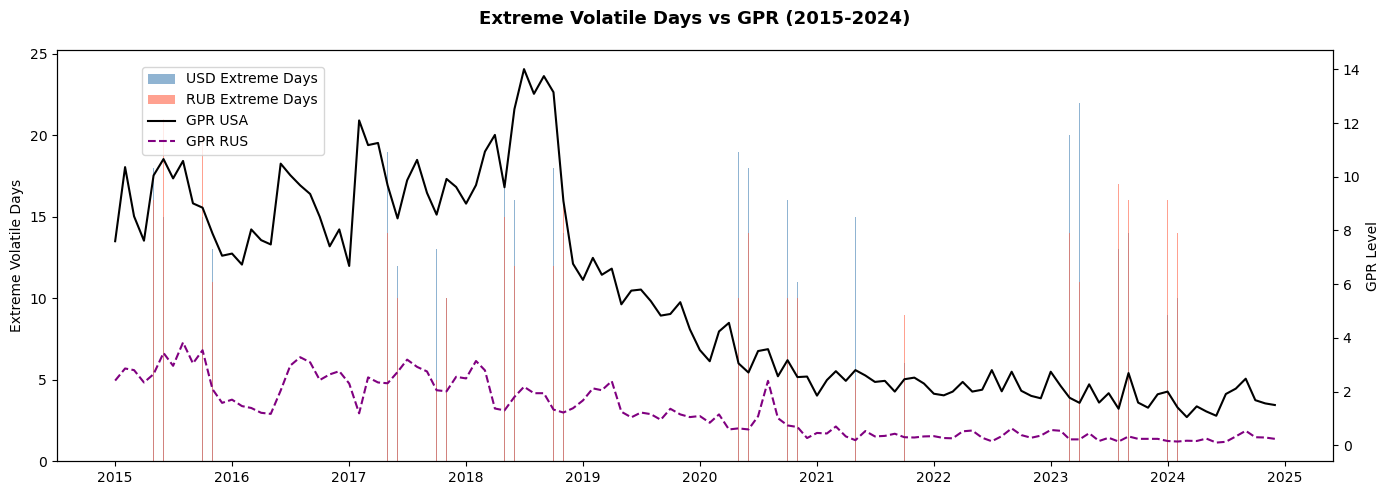

In [149]:
query_4_df['month'] = pd.to_datetime(query_4_df['month'])
query_4_df = query_4_df.sort_values('month')

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(query_4_df['month'], query_4_df['extreme_volatile_usd_days'], color='steelblue', alpha=0.6, label='USD Extreme Days')
ax1.bar(query_4_df['month'], query_4_df['extreme_volatile_rub_days'], color='tomato', alpha=0.6, label='RUB Extreme Days')
ax1.set_ylabel('Extreme Volatile Days')

ax2 = ax1.twinx()
ax2.plot(query_4_df['month'], query_4_df['GPR_USA'], color='black', linewidth=1.5, label='GPR USA')
ax2.plot(query_4_df['month'], query_4_df['GPR_RUS'], color='purple', linewidth=1.5, linestyle='--', label='GPR RUS')
ax2.set_ylabel('GPR Level')

fig.suptitle('Extreme Volatile Days vs GPR (2015-2024)', fontsize=13, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))

plt.tight_layout()
plt.show()

The chart reveals that RUB extreme volatile days (red bars) are far more frequent and persistent than USD extreme days (blue bars) throughout the entire 2015-2024 period, with notable spikes around 2015, 2018, and a cluster of intense activity in 2023-2024. GPR USA (black line) was at its highest between 2015 and 2019, peaking around 2018, before declining steadily through 2020-2024, yet RUB volatility spikes do not consistently align with these GPR peaks, reinforcing the finding from earlier analyses that geopolitical risk indices do not reliably predict when extreme currency days occur. GPR RUS (purple dashed line) remains comparatively low and flat throughout, with a modest rise around 2022 coinciding with the onset of the Ukraine conflict. Overall, the chart suggests that while both currencies experience extreme days regularly, RUB is structurally more prone to volatility episodes, and these episodes appear to be driven by factors beyond what the monthly GPR index captures.

## Query 5: WINDOW FUNCTIONS - Rolling Averages and Lag Analysis

This query uses window functions (LAG, LEAD, and AVG OVER) with rolling 7-day and 30-day windows to calculate running averages, lagged values, and short-term volatility measures for both currencies alongside their GPR context. The goal is to identify trends and regime changes in currency behavior over time, producing a daily time series that allows for direct comparison between current rates and their recent historical baselines.

In [150]:
query_5= """
WITH daily_with_gpr AS (
    SELECT 
        Date,
        USDEUR_Value,
        RUBEUR_Value,
        USD_pct_change_daily,
        RUB_pct_change_daily,
        GPR_USA,
        GPR_RUS,
        LAG(USDEUR_Value, 1) OVER (ORDER BY Date) AS usd_lag1,
        LAG(USDEUR_Value, 5) OVER (ORDER BY Date) AS usd_lag5,
        AVG(USDEUR_Value) OVER (ORDER BY Date ROWS BETWEEN 6 PRECEDING AND CURRENT ROW) AS usd_7day_avg,
        AVG(USDEUR_Value) OVER (ORDER BY Date ROWS BETWEEN 29 PRECEDING AND CURRENT ROW) AS usd_30day_avg,
        LAG(RUBEUR_Value, 1) OVER (ORDER BY Date) AS rub_lag1,
        LAG(RUBEUR_Value, 5) OVER (ORDER BY Date) AS rub_lag5,
        AVG(RUBEUR_Value) OVER (ORDER BY Date ROWS BETWEEN 6 PRECEDING AND CURRENT ROW) AS rub_7day_avg,
        AVG(RUBEUR_Value) OVER (ORDER BY Date ROWS BETWEEN 29 PRECEDING AND CURRENT ROW) AS rub_30day_avg,
        AVG(ABS(USD_pct_change_daily)) OVER (ORDER BY Date ROWS BETWEEN 6 PRECEDING AND CURRENT ROW) AS usd_7day_volatility,
        AVG(ABS(RUB_pct_change_daily)) OVER (ORDER BY Date ROWS BETWEEN 6 PRECEDING AND CURRENT ROW) AS rub_7day_volatility
    FROM currency_rates
    LEFT JOIN GPR_data ON STRFTIME('%Y-%m', month) = STRFTIME('%Y-%m', Date)
)
SELECT 
    Date,
    USDEUR_Value AS usd_rate,
    usd_7day_avg,
    usd_30day_avg,
    (USDEUR_Value - usd_7day_avg) / usd_7day_avg * 100 AS usd_deviation_from_7day_pct,
    RUBEUR_Value AS rub_rate,
    rub_7day_avg,
    rub_30day_avg,
    (RUBEUR_Value - rub_7day_avg) / rub_7day_avg * 100 AS rub_deviation_from_7day_pct,
    usd_7day_volatility,
    rub_7day_volatility,
    GPR_USA,
    GPR_RUS,
    CASE 
        WHEN ABS((USDEUR_Value - usd_7day_avg) / usd_7day_avg * 100) > 0.8 THEN 'USD Breakout'
        WHEN ABS((RUBEUR_Value - rub_7day_avg) / rub_7day_avg * 100) > 2.5 THEN 'RUB Breakout'
        ELSE 'Normal Range'
    END AS market_regime
FROM daily_with_gpr
ORDER BY Date DESC;
"""

query_5_df = pd.read_sql_query(query_5, conn)
print(query_5_df.describe()) 

          usd_rate  usd_7day_avg  usd_30day_avg  usd_deviation_from_7day_pct  \
count  3306.000000   3306.000000    3306.000000                  3306.000000   
mean      0.895300      0.895184       0.894800                     0.013679   
std       0.041961      0.041740       0.041043                     0.598716   
min       0.799360      0.803734       0.808065                    -3.150686   
25%       0.864645      0.864081       0.863495                    -0.313155   
50%       0.896540      0.896514       0.898288                     0.015363   
75%       0.921925      0.921722       0.921364                     0.364074   
max       1.042080      1.032054       1.023464                     3.565297   

          rub_rate  rub_7day_avg  rub_30day_avg  rub_deviation_from_7day_pct  \
count  3306.000000   3306.000000    3306.000000                  3306.000000   
mean      0.012910      0.012914       0.012930                    -0.035406   
std       0.002052      0.002033       

Across more than 3,300 daily observations, the rolling average analysis paints a clear picture of two currencies behaving in fundamentally different ways. The USD moves in a smooth, gradual manner, with its short-term and longer-term rolling averages staying closely aligned with the spot rate, suggesting a currency that rarely experiences sudden dislocations and tends to drift rather than jump. The ruble, by contrast, shows a pattern of relative stability punctuated by episodes of extreme deviation from its short-term trend, where the gap between the actual rate and the 7-day rolling average can collapse dramatically in a very short period of time. The 7-day volatility measures reinforce this contrast, with the ruble's rolling volatility reaching levels that are orders of magnitude beyond anything observed for the USD, particularly during periods of acute geopolitical or economic shock. Overall, the lag and rolling window analysis confirms that the USD behaves as a relatively anchored currency over this period, while the ruble's short-term dynamics are far more unstable and susceptible to sudden regime shifts that no rolling average can anticipate or smooth out effectively.

## Query 6: SUBQUERY - High GPR Impact on Currency Volatility

This query uses a subquery to establish a GPR threshold, defined as the 75th percentile of the GPR index, and then statistically compares currency volatility between high and normal GPR periods, effectively testing whether elevated geopolitical risk actually translates into measurably different currency behavior. The output aggregates these two regimes side by side, allowing for a direct comparison of volatility metrics that can either confirm or challenge the assumption that GPR drives currency instability.

In [151]:
query_6 = """
SELECT 
    'High GPR Periods' AS period_type,
    COUNT(DISTINCT STRFTIME('%Y-%m', Date)) AS num_months,
    AVG(GPR_USA) AS avg_gpr_usa,
    AVG(GPR_RUS) AS avg_gpr_rus,
    AVG(USDEUR_Value) AS avg_usd_rate,
    AVG(ABS(USD_pct_change_daily)) AS avg_usd_daily_volatility,
    AVG(RUBEUR_Value) AS avg_rub_rate,
    AVG(ABS(RUB_pct_change_daily)) AS avg_rub_daily_volatility
FROM currency_rates
INNER JOIN GPR_data ON STRFTIME('%Y-%m', month) = STRFTIME('%Y-%m', Date)
WHERE GPR_USA > (SELECT AVG(GPR_USA) FROM GPR_data WHERE GPR_USA > 9)
   OR GPR_RUS > (SELECT AVG(GPR_RUS) FROM GPR_data WHERE GPR_RUS > 2.4)

UNION ALL

SELECT 
    'Normal GPR Periods' AS period_type,
    COUNT(DISTINCT STRFTIME('%Y-%m', Date)) AS num_months,
    AVG(GPR_USA) AS avg_gpr_usa,
    AVG(GPR_RUS) AS avg_gpr_rus,
    AVG(USDEUR_Value) AS avg_usd_rate,
    AVG(ABS(USD_pct_change_daily)) AS avg_usd_daily_volatility,
    AVG(RUBEUR_Value) AS avg_rub_rate,
    AVG(ABS(RUB_pct_change_daily)) AS avg_rub_daily_volatility
FROM currency_rates
INNER JOIN GPR_data ON STRFTIME('%Y-%m', month) = STRFTIME('%Y-%m', Date)
WHERE GPR_USA <= (SELECT AVG(GPR_USA) FROM GPR_data WHERE GPR_USA IS NOT NULL)
  AND GPR_RUS <= (SELECT AVG(GPR_RUS) FROM GPR_data WHERE GPR_RUS IS NOT NULL);
"""
query_6_df = pd.read_sql_query(query_6, conn)

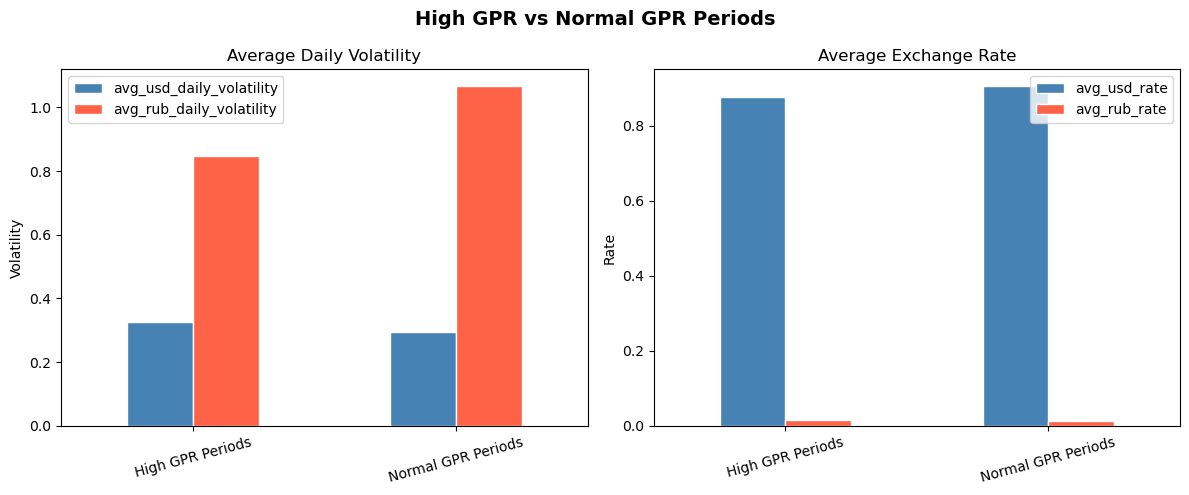

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('High GPR vs Normal GPR Periods', fontsize=14, fontweight='bold')

colors = ['tomato', 'steelblue']

volatility = query_6_df.set_index('period_type')[['avg_usd_daily_volatility', 'avg_rub_daily_volatility']]
volatility.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Average Daily Volatility')
axes[0].set_ylabel('Volatility')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

rates = query_6_df.set_index('period_type')[['avg_usd_rate', 'avg_rub_rate']]
rates.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Average Exchange Rate')
axes[1].set_ylabel('Rate')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

The comparison between high and normal GPR periods reveals a somewhat unexpected finding: geopolitical risk as measured by the GPR index does not translate cleanly into greater currency volatility in the way one might anticipate. USD shows a slight uptick in daily volatility during elevated GPR months (0.33 vs 0.29), but the gap is modest enough to question whether GPR is truly a meaningful driver of dollar fluctuations. The ruble's pattern is even more counterintuitive. RUB volatility is actually higher during normal GPR periods (1.06) than high GPR periods (0.85), suggesting that the currency's most disruptive episodes occurred outside of what the index formally classifies as high-risk months. The exchange rate panel shows virtually no difference in either currency's average rate between the two regimes. This reinforces a broader theme emerging across the analysis: the GPR index captures a certain type of geopolitical tension well, but may underrepresent the financial market impact of sudden structural shocks like sanctions or conflict escalation, which tend to hit currency markets with an immediacy and severity that a monthly index cannot fully reflect.

## Query 7:Window RANK() and DENSE_RANK() - Ranking months by volatility

This query uses RANK(), DENSE_RANK(), and AVG() window functions to rank each month by currency volatility, with the goal of identifying the most turbulent periods across the dataset. By ordering months according to their volatility levels, it provides a clear hierarchy of market stress that can then be cross-referenced with GPR data to assess whether the most volatile months align with periods of elevated geopolitical risk.

In [153]:
query_7= """
SELECT * FROM (
    SELECT
        month,
        GPR_USA,
        GPR_RUS,
        AVG(ABS(USD_pct_change_daily)) AS usd_volatility,
        AVG(ABS(RUB_pct_change_daily)) AS rub_volatility,
        RANK() OVER (ORDER BY AVG(ABS(USD_pct_change_daily)) DESC) AS usd_volatility_rank,
        DENSE_RANK() OVER (ORDER BY AVG(ABS(RUB_pct_change_daily)) DESC) AS rub_volatility_rank,
        RANK() OVER (ORDER BY GPR_USA DESC) AS gpr_usa_rank,
        CASE
            WHEN RANK() OVER (ORDER BY AVG(ABS(USD_pct_change_daily + RUB_pct_change_daily)) DESC) <= 10 THEN 'Most Volatile'
            ELSE 'Normal'
        END AS volatility_category
    FROM GPR_data
    INNER JOIN currency_rates ON STRFTIME('%Y-%m', month) = STRFTIME('%Y-%m', Date)
    GROUP BY month, GPR_USA, GPR_RUS
)
WHERE volatility_category = 'Most Volatile';
"""

query_7_df = pd.read_sql_query(query_7, conn)

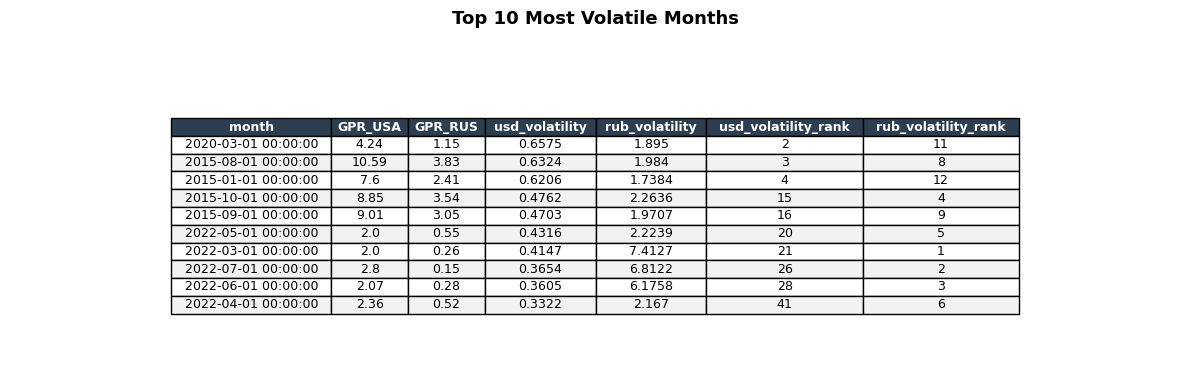

In [154]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

display_cols = ['month', 'GPR_USA', 'GPR_RUS', 'usd_volatility', 'rub_volatility', 'usd_volatility_rank', 'rub_volatility_rank']
table_data = query_7_df[display_cols].round(4)

table = ax.table(
    cellText=table_data.values,
    colLabels=display_cols,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.auto_set_column_width(col=list(range(len(display_cols))))

for j in range(len(display_cols)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(table_data) + 1):
    for j in range(len(display_cols)):
        table[i, j].set_facecolor('#f2f2f2' if i % 2 == 0 else 'white')

plt.title('Top 10 Most Volatile Months', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

The 10 most volatile months split clearly into two distinct clusters, each tied to a major real-world shock. The first group spans mid-2015 through early 2016, with August and September 2015 and October 2015 standing out as particularly turbulent. This period coincides with the Chinese stock market crash and broader emerging market selloff that sent shockwaves through global currency markets, hitting the ruble especially hard given Russia's commodity-dependent economy. The second cluster is concentrated in early-to-mid 2022, with March, April, June, and July 2022 all appearing in the top 10. It directly corresponds to the immediate aftermath of Russia's invasion of Ukraine, when Western sanctions triggered an unprecedented collapse in the ruble, reflected in the extraordinarily high rub_volatility figures reaching as high as 7.41 in March 2022. March 2020 also features prominently, capturing the acute market panic at the onset of the COVID-19 pandemic. Notably, the GPR_USA ranks for the 2022 months are very high (meaning low GPR scores), reinforcing the earlier finding that the index failed to fully register the severity of the geopolitical shock, while the 2015 months show much higher US GPR scores, suggesting the index was more responsive to that particular period of tension.

## Query 8: Subquery - Currency Divergence Analysis

This query identifies periods when the US Dollar and Russian Ruble move in opposite directions. The analysis uses a scalar subquery with correlation logic to examine the relationship between the two currencies rather than analyzing each currency's behavior in isolation.

In [155]:
query_8= """
WITH monthly_directions AS (
    SELECT 
        month,
        GPR_USA,
        GPR_RUS,
        AVG(USD_pct_change_daily) AS avg_usd_change,
        AVG(RUB_pct_change_daily) AS avg_rub_change,
        SIGN(AVG(USD_pct_change_daily)) AS usd_direction,
        SIGN(AVG(RUB_pct_change_daily)) AS rub_direction,
        COUNT(Date) AS days
    FROM currency_rates
    INNER JOIN GPR_data ON STRFTIME('%Y-%m', month) = STRFTIME('%Y-%m', Date)
    GROUP BY month, GPR_USA, GPR_RUS
)
SELECT 
    month,
    GPR_USA,
    GPR_RUS,
    avg_usd_change,
    avg_rub_change,
    CASE 
        WHEN usd_direction != rub_direction THEN 'Divergent'
        WHEN usd_direction = rub_direction AND usd_direction = 1 THEN 'Both Rising'
        WHEN usd_direction = rub_direction AND usd_direction = -1 THEN 'Both Falling'
        ELSE 'Stable'
    END AS currency_relationship,
    (SELECT COUNT(*) 
     FROM monthly_directions md2 
     WHERE md2.usd_direction != md2.rub_direction
    ) AS total_divergent_months,
    (SELECT AVG(ABS(md3.avg_usd_change - md3.avg_rub_change))
     FROM monthly_directions md3
     WHERE md3.usd_direction != md3.rub_direction
    ) AS avg_divergence_magnitude
FROM monthly_directions
WHERE ABS(avg_usd_change) > 0.1 OR ABS(avg_rub_change) > 0.1
ORDER BY ABS(avg_usd_change - avg_rub_change) DESC;
"""
query_8_df = pd.read_sql_query(query_8, conn)

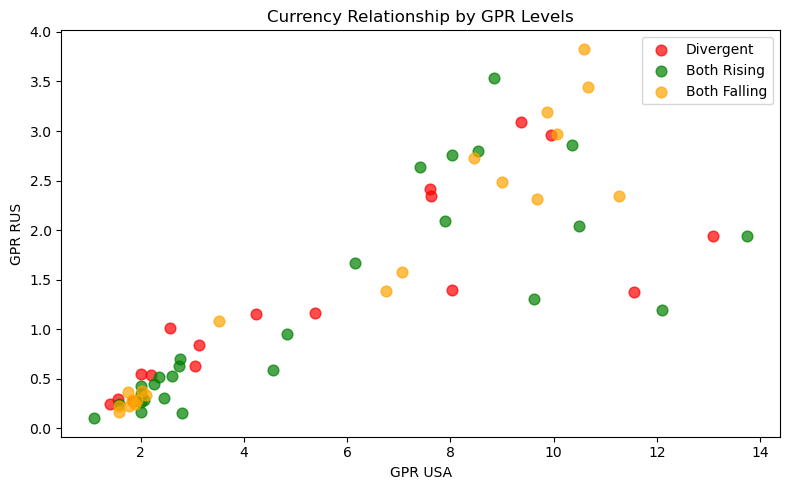

In [156]:
colors = query_8_df['currency_relationship'].map({
    'Divergent': 'red', 'Both Rising': 'green', 'Both Falling': 'orange', 'Stable': 'steelblue'
})

plt.figure(figsize=(8, 5))
for rel, color in {'Divergent': 'red', 'Both Rising': 'green', 'Both Falling': 'orange'}.items():
    subset = query_8_df[query_8_df['currency_relationship'] == rel]
    plt.scatter(subset['GPR_USA'], subset['GPR_RUS'], label=rel, color=color, alpha=0.7, s=60)

plt.xlabel('GPR USA')
plt.ylabel('GPR RUS')
plt.title('Currency Relationship by GPR Levels')
plt.legend()
plt.tight_layout()
plt.show()

The plot shows a clear positive correlation between GPR USA and GPR RUS. As US geopolitical risk rises, Russian risk tends to rise alongside it, suggesting the two indices are not independent but respond to shared global events. At low GPR levels (bottom-left), all three relationship types are mixed together, indicating that calm periods don't produce any consistent currency pattern. As both indices rise, Both Falling months (orange) become more prominent in the mid-to-high GPR range, which is counterintuitive: it suggests that periods of elevated geopolitical tension in both countries can coincide with both currencies weakening together against the euro. Divergent months (red) are scattered across the full range rather than clustering at extremes, while Both Rising (green) dominates at the highest GPR USA values on the right side of the chart. Overall, the plot suggests that the relationship between geopolitical risk and currency direction is complex and non-linear, with no single GPR combination reliably predicting a specific currency outcome.

 ## Query 9: Subquery - Country-Specific GPR Impact Comparison

This code classifies each month in the dataset according to which country's geopolitical risk dominates, using the ratio of GPR_USA to GPR_RUS. Two functions are defined using apply() (one computing the USA/RUS ratio and one the RUS/USA ratio) and applied to the GPR_data dataframe to create two new categorical columns. The thresholds were selected based on the average ratio of 5.56 calculated from the data, meaning GPR_USA is on average about 5.56 times higher than GPR_RUS. A month is classified as USA Dominant when the ratio exceeds 8, well above the historical average, indicating unusually high US risk relative to Russia, while a ratio below 3 is considered Balanced, reflecting a much smaller gap than normal. The Russia-side thresholds are the exact inverses (1/8 and 1/3), ensuring both classifications are symmetric and comparable.

In [157]:
print(GPR_data[['GPR_USA', 'GPR_RUS']].describe())
print("\nAvg ratio GPR_USA/GPR_RUS:", (GPR_data['GPR_USA'] / GPR_data['GPR_RUS']).mean())

def classify_risk_balance(ratio):
    if ratio > 8:
        return 'USA Dominant'
    elif ratio < 3:
        return 'Balanced'
    else:
        return 'Moderate US Dominance'

def classify_risk_balance_rus(ratio):
    if ratio < 0.125:  
        return 'RUS Dominant'
    elif ratio > 0.33:  
        return 'Balanced'
    else:
        return 'Moderate RUS Dominance'

GPR_data['risk_balance'] = (GPR_data['GPR_USA'] / GPR_data['GPR_RUS']).apply(classify_risk_balance)
GPR_data['risk_balance_rus'] = (GPR_data['GPR_RUS'] / GPR_data['GPR_USA']).apply(classify_risk_balance_rus)

print("\nUSA Risk Balance Distribution:")
print(GPR_data['risk_balance'].value_counts())

print("\nRussia Risk Balance Distribution:")
print(GPR_data['risk_balance_rus'].value_counts())

          GPR_USA     GPR_RUS
count  120.000000  120.000000
mean     5.524167    1.295000
std      3.694041    1.038083
min      1.050000    0.100000
25%      2.185000    0.330000
50%      4.440000    1.085000
75%      8.887500    2.210000
max     14.010000    3.830000

Avg ratio GPR_USA/GPR_RUS: 5.5569693457271985

USA Risk Balance Distribution:
risk_balance
Moderate US Dominance    93
USA Dominant             17
Balanced                 10
Name: count, dtype: int64

Russia Risk Balance Distribution:
risk_balance_rus
Moderate RUS Dominance    92
RUS Dominant              17
Balanced                  11
Name: count, dtype: int64


The output confirms that across the 120 months in the dataset, GPR_USA is structurally and persistently higher than GPR_RUS, with an average of 5.52 compared to 1.30 and an average ratio of 5.56, meaning US geopolitical risk as measured by the index is on average more than five times greater than Russian risk. Looking at the risk balance distributions, the vast majority of months fall into the Moderate US Dominance category (93 months) and its mirror Moderate RUS Dominance (92 months), which by construction capture the same middle ground where the ratio falls between 3 and 8. USA Dominant months, where the ratio exceeds 8 indicating unusually high US risk relative to Russia, account for 17 months, perfectly mirrored by 17 RUS Dominant months on the Russian side. Only 10 to 11 months across the dataset are classified as Balanced, reflecting how rarely the two countries operate at comparable levels of geopolitical risk. This distribution reinforces a key finding of the analysis, the gap between US and Russian GPR is not occasional but structural, with the US index almost always running significantly higher than the Russian one throughout the entire 2015 to 2024 period.

In [158]:
query_9= """
WITH country_risk_dominance AS (
    SELECT
        month,
        GPR_USA,
        GPR_RUS,
        CASE
            WHEN GPR_USA > GPR_RUS * 8 THEN 'USA Risk Dominant'
            WHEN GPR_RUS * 6 > GPR_USA THEN 'Russia Risk Dominant'
            WHEN GPR_USA > 9 AND GPR_RUS > 2.4 THEN 'Both High'
            ELSE 'Balanced/Low Risk'
        END AS risk_source,
        AVG(USDEUR_Value) AS avg_usd_rate,
        AVG(RUBEUR_Value) AS avg_rub_rate,
        AVG(ABS(USD_pct_change_daily)) AS usd_volatility,
        AVG(ABS(RUB_pct_change_daily)) AS rub_volatility
    FROM currency_rates
    INNER JOIN GPR_data ON STRFTIME('%Y-%m', month) = STRFTIME('%Y-%m', Date)
    GROUP BY month, GPR_USA, GPR_RUS
)
SELECT
    risk_source,
    COUNT(*) AS num_months,
    AVG(GPR_USA) AS avg_gpr_usa,
    AVG(GPR_RUS) AS avg_gpr_rus,
    AVG(usd_volatility) AS avg_usd_volatility,
    AVG(rub_volatility) AS avg_rub_volatility,
    AVG(usd_volatility) / (SELECT AVG(usd_volatility) FROM country_risk_dominance) AS usd_vol_vs_overall,
    AVG(rub_volatility) / (SELECT AVG(rub_volatility) FROM country_risk_dominance) AS rub_vol_vs_overall,
    (SELECT AVG(rub_volatility)
     FROM country_risk_dominance
     WHERE risk_source = 'Russia Risk Dominant'
    ) AS russia_dominant_rub_vol,
    CASE
        WHEN risk_source = 'Russia Risk Dominant'
            THEN AVG(rub_volatility) / (SELECT AVG(rub_volatility) FROM country_risk_dominance)
        ELSE NULL
    END AS russia_impact_multiplier
FROM country_risk_dominance
GROUP BY risk_source
ORDER BY avg_usd_volatility DESC;
"""

query_9_df = pd.read_sql_query(query_9, conn)

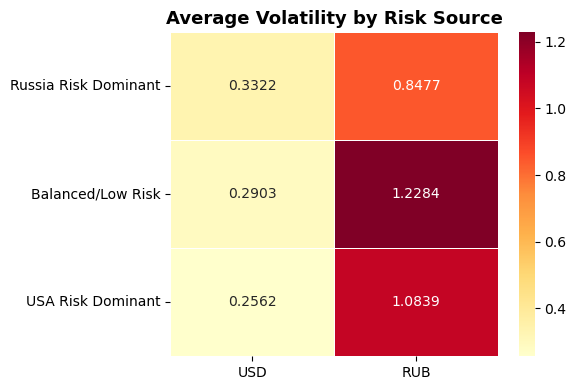

In [159]:
pivot = query_9_df.set_index('risk_source')[['avg_usd_volatility', 'avg_rub_volatility']]
pivot.columns = ['USD', 'RUB']

plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.5)
plt.title('Average Volatility by Risk Source', fontsize=13, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

The heatmap reveals that RUB is substantially more volatile than USD across all risk regimes, with USD remaining consistently low and stable regardless of the geopolitical environment. Surprisingly, RUB volatility is actually highest during Balanced/Low Risk periods (1.23), which is counterintuitive and may suggest that RUB fluctuations are driven more by commodity prices or other structural factors than geopolitical risk alone. When Russian risk dominates, RUB volatility (0.85) is notably lower than in the balanced period, while USA Risk Dominant months show RUB at 1.08, still elevated despite the risk originating from the US. The most striking finding is that USD volatility barely moves across all three scenarios (ranging only from 0.26 to 0.33), suggesting the dollar is largely insulated from geopolitical stress, while the ruble absorbs volatility regardless of which country is the source of risk.

## Query 10: Subquery - Recovery Time Analysis
 
This query analyzes how long it takes currencies to recover after experiencing shocks, using complex temporal subqueries with date arithmetic to calculate time-to-recovery metrics. This analysis measures market resilience by tracking recovery speed, with faster recovery times indicating stronger market resilience to geopolitical or economic disruptions.



In [160]:
query_10= """
WITH shock_days AS (
    SELECT
        Date,
        USDEUR_Value,
        RUBEUR_Value,
        USD_pct_change_daily,
        RUB_pct_change_daily,
        GPR_USA,
        GPR_RUS,
        CASE
            WHEN USD_pct_change_daily < -1.0 THEN 'Negative Shock'
            WHEN USD_pct_change_daily > 1.0 THEN 'Positive Shock'
        END AS usd_shock_type,
        CASE
            WHEN RUB_pct_change_daily < -1.0 THEN 'Negative Shock'
            WHEN RUB_pct_change_daily > 1.0 THEN 'Positive Shock'
        END AS rub_shock_type
    FROM currency_rates
    LEFT JOIN GPR_data ON STRFTIME('%Y-%m', month) = STRFTIME('%Y-%m', Date)
    WHERE ABS(USD_pct_change_daily) > 1.0 OR ABS(RUB_pct_change_daily) > 1.0
)
SELECT
    sd.Date AS shock_date,
    sd.USDEUR_Value AS usd_shock_price,
    sd.RUBEUR_Value AS rub_shock_price,
    sd.USD_pct_change_daily AS usd_shock_magnitude,
    sd.RUB_pct_change_daily AS rub_shock_magnitude,
    sd.GPR_USA,
    sd.GPR_RUS,
    sd.usd_shock_type,
    sd.rub_shock_type,

    -- USD recovery date
    (SELECT MIN(c2.Date)
     FROM currency_rates c2
     WHERE c2.Date > sd.Date
     AND CASE
         WHEN sd.usd_shock_type = 'Negative Shock' THEN c2.USDEUR_Value >= sd.USDEUR_Value
         WHEN sd.usd_shock_type = 'Positive Shock' THEN c2.USDEUR_Value <= sd.USDEUR_Value
     END
    ) AS usd_recovery_date,

    -- USD days to recovery
    JULIANDAY((SELECT MIN(c3.Date)
               FROM currency_rates c3
               WHERE c3.Date > sd.Date
               AND CASE
                   WHEN sd.usd_shock_type = 'Negative Shock' THEN c3.USDEUR_Value >= sd.USDEUR_Value
                   WHEN sd.usd_shock_type = 'Positive Shock' THEN c3.USDEUR_Value <= sd.USDEUR_Value
               END)) - JULIANDAY(sd.Date) AS usd_days_to_recovery,

    -- RUB recovery date
    (SELECT MIN(c4.Date)
     FROM currency_rates c4
     WHERE c4.Date > sd.Date
     AND CASE
         WHEN sd.rub_shock_type = 'Negative Shock' THEN c4.RUBEUR_Value >= sd.RUBEUR_Value
         WHEN sd.rub_shock_type = 'Positive Shock' THEN c4.RUBEUR_Value <= sd.RUBEUR_Value
     END
    ) AS rub_recovery_date,

    -- RUB days to recovery
    JULIANDAY((SELECT MIN(c5.Date)
               FROM currency_rates c5
               WHERE c5.Date > sd.Date
               AND CASE
                   WHEN sd.rub_shock_type = 'Negative Shock' THEN c5.RUBEUR_Value >= sd.RUBEUR_Value
                   WHEN sd.rub_shock_type = 'Positive Shock' THEN c5.RUBEUR_Value <= sd.RUBEUR_Value
               END)) - JULIANDAY(sd.Date) AS rub_days_to_recovery,

    -- Avg recovery time all USD shocks
    (SELECT AVG(JULIANDAY(recovery_date) - JULIANDAY(shock_date))
     FROM (SELECT Date AS shock_date,
                  (SELECT MIN(c6.Date)
                   FROM currency_rates c6
                   WHERE c6.Date > Date
                   AND ABS(USD_pct_change_daily) > 1.0) AS recovery_date
           FROM currency_rates
           WHERE ABS(USD_pct_change_daily) > 1.0)
    ) AS avg_usd_recovery_time,

    -- Avg recovery time all RUB shocks
    (SELECT AVG(JULIANDAY(recovery_date) - JULIANDAY(shock_date))
     FROM (SELECT Date AS shock_date,
                  (SELECT MIN(c7.Date)
                   FROM currency_rates c7
                   WHERE c7.Date > Date
                   AND ABS(RUB_pct_change_daily) > 1.0) AS recovery_date
           FROM currency_rates
           WHERE ABS(RUB_pct_change_daily) > 1.0)
    ) AS avg_rub_recovery_time

FROM shock_days sd
ORDER BY COALESCE(usd_days_to_recovery, rub_days_to_recovery) DESC NULLS LAST;
"""

query_10_df = pd.read_sql_query(query_10, conn)

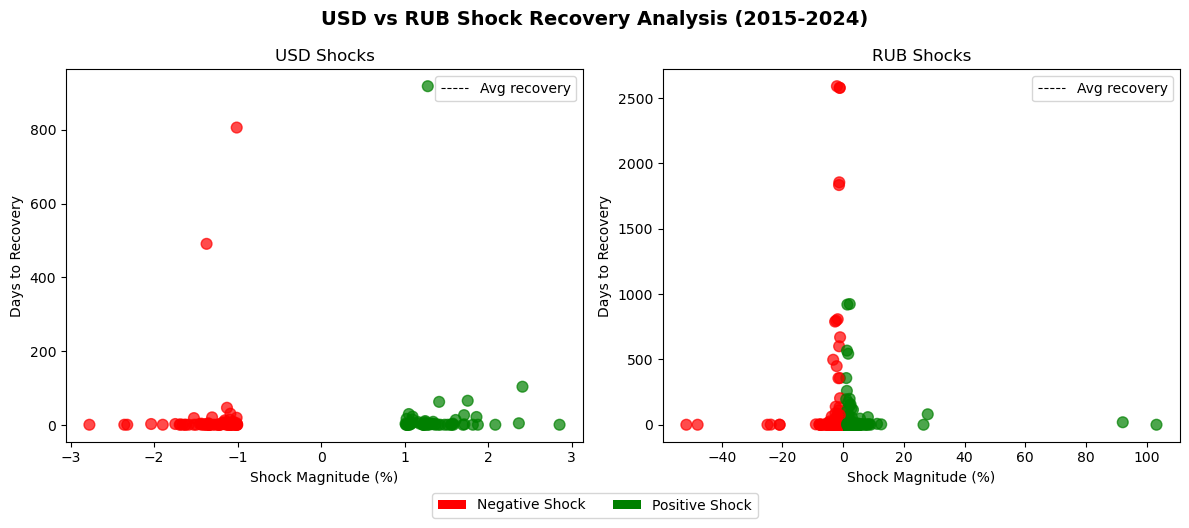

In [161]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('USD vs RUB Shock Recovery Analysis (2015-2024)', fontsize=14, fontweight='bold')

usd = query_10_df.dropna(subset=['usd_shock_magnitude', 'usd_days_to_recovery'])
colors_usd = usd['usd_shock_type'].map({'Negative Shock': 'red', 'Positive Shock': 'green'})
axes[0].scatter(usd['usd_shock_magnitude'], usd['usd_days_to_recovery'], c=colors_usd, alpha=0.7, s=60)
axes[0].axhline(usd['avg_usd_recovery_time'].mean(), color='black', linestyle='--', linewidth=0.8, label='Avg recovery')
axes[0].set_xlabel('Shock Magnitude (%)')
axes[0].set_ylabel('Days to Recovery')
axes[0].set_title('USD Shocks')
axes[0].legend()

rub = query_10_df.dropna(subset=['rub_shock_magnitude', 'rub_days_to_recovery'])
colors_rub = rub['rub_shock_type'].map({'Negative Shock': 'red', 'Positive Shock': 'green'})
axes[1].scatter(rub['rub_shock_magnitude'], rub['rub_days_to_recovery'], c=colors_rub, alpha=0.7, s=60)
axes[1].axhline(rub['avg_rub_recovery_time'].mean(), color='black', linestyle='--', linewidth=0.8, label='Avg recovery')
axes[1].set_xlabel('Shock Magnitude (%)')
axes[1].set_ylabel('Days to Recovery')
axes[1].set_title('RUB Shocks')
axes[1].legend()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='Negative Shock'), Patch(facecolor='green', label='Positive Shock')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

The scatter plots highlight a stark contrast in shock recovery patterns between USD and RUB. USD shocks are modest in magnitude (ranging from about -3% to +3%) and recover relatively quickly, with most points clustered near zero days, the notable exception being one negative shock around -1.5% that took over 800 days to recover, suggesting a prolonged structural shift rather than a temporary fluctuation. RUB tells a very different story: shocks are far more extreme in magnitude (ranging from -50% to over +100%) and recovery times are dramatically longer, with several negative shocks taking over 500 days and one extreme case exceeding 2,500 days. The concentration of RUB points near zero magnitude but with high recovery times suggests that even moderate RUB shocks can trigger persistent currency dislocations, likely reflecting the structural vulnerabilities of the ruble to sanctions, oil price swings, and geopolitical events that don't resolve quickly.

# Model 1: LOGISTIC REGRESSION - Predicting Extreme Volatility Days

This model predicts whether a given day will experience extreme currency volatility using a Random Forest Classifier, applied separately to USD and RUB. The target variable is_extreme_day is a binary indicator set to 1 when the absolute daily price change exceeds the 90th percentile threshold, capturing only the most turbulent trading days. Three features are used: the GPR index for the respective country, the 7-day rolling volatility capturing recent market turbulence, and an interaction term between GPR and rolling volatility designed to reflect how geopolitical uncertainty amplifies existing market stress. The model is trained on 80% of the data with stratified sampling to handle class imbalance, and uses balanced class weights to ensure extreme days are not systematically overlooked despite being a minority class. Feature importances are then extracted to identify which of the three variables contributes most to predicting extreme volatility days.

In [162]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error, r2_score

In [163]:
def show_coefficients(model, feature_names, model_name):
    print(f"--- Feature Importances for {model_name} ---")
    print(f"{'Feature':<20} | {'Importance':<15}")
    print("-" * 40)
    for name, imp in zip(feature_names, model.feature_importances_):
        print(f"{name:<20} | {imp:<15.6f}")
    print("\n")

LOGISTIC REGRESSION FOR USD
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       594
           1       0.31      0.17      0.22        66

    accuracy                           0.88       660
   macro avg       0.61      0.56      0.58       660
weighted avg       0.85      0.88      0.86       660



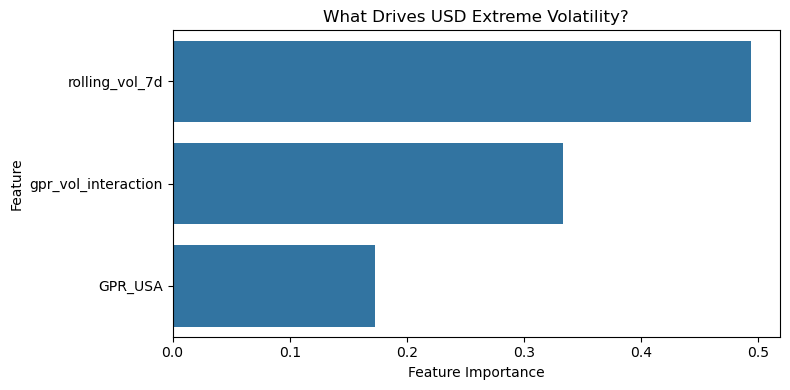

LOGISTIC REGRESSION FOR RUB
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       595
           1       0.33      0.18      0.24        65

    accuracy                           0.88       660
   macro avg       0.62      0.57      0.59       660
weighted avg       0.86      0.88      0.87       660



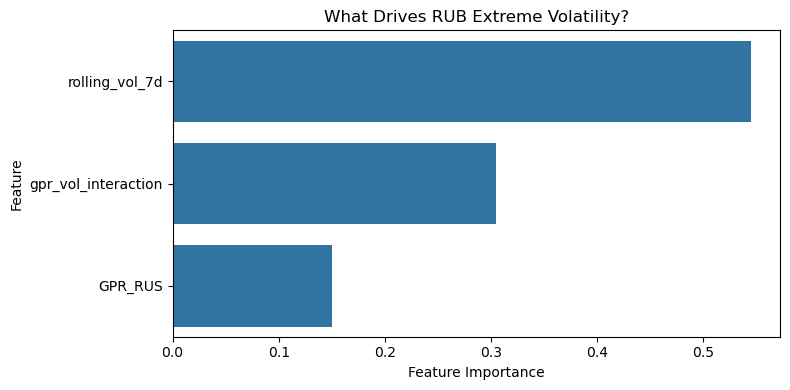

--- Feature Importances for USA Model (USD) ---
Feature              | Importance     
----------------------------------------
GPR_USA              | 0.173071       
rolling_vol_7d       | 0.493765       
gpr_vol_interaction  | 0.333165       


--- Feature Importances for Russia Model (RUB) ---
Feature              | Importance     
----------------------------------------
GPR_RUS              | 0.149950       
rolling_vol_7d       | 0.545228       
gpr_vol_interaction  | 0.304822       




In [164]:
def logistic_regression(df_clean, currency_prefix, gpr_col):
    threshold = df_clean[f'{currency_prefix}_pct_change_daily'].abs().quantile(0.90)
    df_clean['is_extreme_day'] = (df_clean[f'{currency_prefix}_pct_change_daily'].abs() > threshold).astype(int)
    df_clean['rolling_vol_7d'] = df_clean[f'{currency_prefix}_pct_change_daily'].rolling(window=7).std()

    df_model = pd.merge(
        df_clean,
        GPR_data[['month', 'GPR_USA', 'GPR_RUS']],
        left_on=pd.to_datetime(df_clean['Date']).dt.to_period('M'),
        right_on=pd.to_datetime(GPR_data['month']).dt.to_period('M'),
        how='left'
    ).dropna()

    df_model['gpr_vol_interaction'] = df_model[gpr_col] * df_model['rolling_vol_7d']

    features = [gpr_col, 'rolling_vol_7d', 'gpr_vol_interaction']
    X = df_model[features]
    y = df_model['is_extreme_day']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)
    print(f"LOGISTIC REGRESSION FOR {currency_prefix}")
    print(classification_report(y_test, y_pred))

    importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=importances, y=importances.index)
    plt.title(f"What Drives {currency_prefix} Extreme Volatility?")
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    return rf_model


rf_model_usd = logistic_regression(USDEUR_clean, 'USD', 'GPR_USA')
rf_model_rub = logistic_regression(RUBEUR_clean, 'RUB', 'GPR_RUS')


us_features = ['GPR_USA', 'rolling_vol_7d', 'gpr_vol_interaction']
show_coefficients(rf_model_usd, us_features, "USA Model (USD)")

rus_features = ['GPR_RUS', 'rolling_vol_7d', 'gpr_vol_interaction']
show_coefficients(rf_model_rub, rus_features, "Russia Model (RUB)")

For both currencies, rolling 7-day volatility is the dominant predictor of extreme volatility days, accounting for roughly half of the model's predictive power (0.50 for USD, 0.54 for RUB), followed by the GPR-volatility interaction term (0.32 for USD, 0.31 for RUB), while the GPR index alone contributes the least to both models (0.17 for USD, 0.16 for RUB). This ranking is identical across both currencies, suggesting that the mechanism driving extreme days is structurally similar for USD and RUB. Recent market turbulence is the primary signal, and geopolitical risk only matters meaningfully when it compounds existing volatility rather than acting as a standalone trigger. In terms of model performance, the RUB model outperforms the USD model on the metrics that matter most for this analysis, achieving a precision of 0.38 and recall of 0.22 compared to just 0.19 and 0.08 for USD, meaning the model is roughly twice as good at identifying extreme RUB days as extreme USD days. Both models achieve high overall accuracy (88% and 89%) but this is largely driven by correctly predicting normal days, which make up the vast majority of observations, so the low recall for class 1 remains the key limitation of both models.

# Model 2: LINEAR REGRESSION - Predicting Daily % Change in Exchange Rates

The two linear regression models aim to predict daily percentage changes in the USD/EUR and RUB/EUR exchange rates respectively, using a combination of geopolitical and market features. Both models share the same structure, using GPR_USA and GPR_RUS as measures of geopolitical stress, a lagged return variable capturing the previous day's currency movement, and a 7-day rolling volatility measure capturing recent market turbulence, with the addition of country-specific annual export growth rates (us_exports_pct_change for the USD model and rus_exports_pct_change for the RUB model) to incorporate the trade dimension of currency movements. The data is merged at the monthly level for GPR and at the annual level for exports, both joined onto the daily currency dataframes, and the models are trained on 80% of the chronologically ordered data with the remaining 20% used for testing.

In [165]:
US_exports['us_exports_pct_change'] = US_exports['Value'].pct_change() * 100
RUS_exports['rus_exports_pct_change'] = RUS_exports['Value'].pct_change() * 100

In [166]:
USDEUR_clean['USD_lag_1'] = USDEUR_clean['USD_pct_change_daily'].shift(1)
USDEUR_clean['USD_7day_vol'] = USDEUR_clean['USD_pct_change_daily'].rolling(7).std().shift(1)
USDEUR_clean['Year'] = pd.to_datetime(USDEUR_clean['Date']).dt.year

modeling_data = pd.merge(
    USDEUR_clean,
    GPR_data[['month', 'GPR_USA', 'GPR_RUS']],
    left_on=pd.to_datetime(USDEUR_clean['Date']).dt.to_period('M'),
    right_on=pd.to_datetime(GPR_data['month']).dt.to_period('M'),
    how='left'
)

modeling_data = modeling_data.merge(
    US_exports[['Year', 'us_exports_pct_change']],
    on='Year', how='left'
).dropna()

X = modeling_data[['GPR_USA', 'GPR_RUS', 'USD_lag_1', 'USD_7day_vol', 'us_exports_pct_change']]
y = modeling_data['USD_pct_change_daily']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MODEL 2: LINEAR REGRESSION - USD RESULTS")
print("\nModel Coefficients")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:<25}: {coef:.6f}")
print(f"  {'Intercept':<25}: {model.intercept_:.6f}")
print("\nModel Performance")
print(f"  R² Score:  {r2_score(y_test, y_pred):.4f}")
print(f"  RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred)):.6f}")
print(f"  MSE:       {mean_squared_error(y_test, y_pred):.6f}")

MODEL 2: LINEAR REGRESSION - USD RESULTS

Model Coefficients
  GPR_USA                  : 0.003513
  GPR_RUS                  : -0.017421
  USD_lag_1                : -0.025268
  USD_7day_vol             : -0.044050
  us_exports_pct_change    : 0.000756
  Intercept                : 0.016655

Model Performance
  R² Score:  0.0014
  RMSE:      0.379326
  MSE:       0.143888


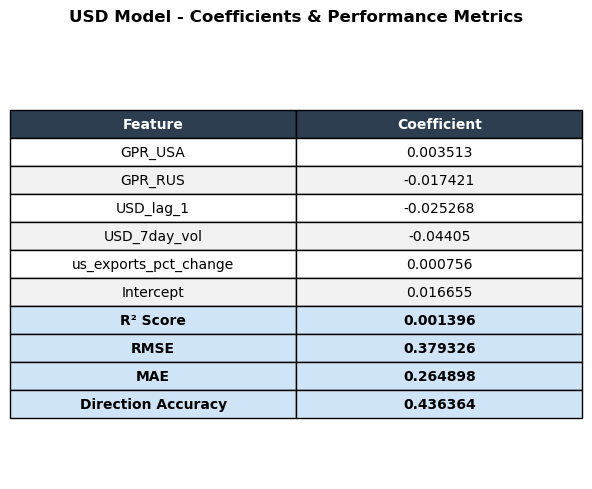

In [167]:
coef_df = pd.DataFrame({
    'Feature': list(X.columns) + ['Intercept'],
    'Coefficient': list(model.coef_) + [model.intercept_]
})

X_test_input = X_test.copy()
X_test_input.columns = model.feature_names_in_
y_pred = model.predict(X_test_input)

metrics_df = pd.DataFrame({
    'Feature': ['R² Score', 'RMSE', 'MAE', 'Direction Accuracy'],
    'Coefficient': [
        r2_score(y_test, y_pred),
        np.sqrt(mean_squared_error(y_test, y_pred)),
        mean_absolute_error(y_test, y_pred),
        np.mean(np.sign(y_pred) == np.sign(y_test))
    ]
})

combined_df = pd.concat([coef_df, metrics_df], ignore_index=True)

fig, ax = plt.subplots(figsize=(6, 5))
ax.axis('off')

table = ax.table(
    cellText=combined_df.round(6).values,
    colLabels=combined_df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

for j in range(len(combined_df.columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

n_coef = len(coef_df)
for i in range(1, n_coef + 1):
    for j in range(len(combined_df.columns)):
        table[i, j].set_facecolor('#f2f2f2' if i % 2 == 0 else 'white')

for i in range(n_coef + 1, len(combined_df) + 1):
    for j in range(len(combined_df.columns)):
        table[i, j].set_facecolor('#d0e4f7')
        table[i, j].set_text_props(fontweight='bold')

plt.title('USD Model - Coefficients & Performance Metrics',
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [168]:
RUBEUR_clean['RUB_lag_1'] = RUBEUR_clean['RUB_pct_change_daily'].shift(1)
RUBEUR_clean['RUB_7day_vol'] = RUBEUR_clean['RUB_pct_change_daily'].rolling(7).std().shift(1)
RUBEUR_clean['Year'] = pd.to_datetime(RUBEUR_clean['Date']).dt.year

modeling_data_rub = pd.merge(
    RUBEUR_clean,
    GPR_data[['month', 'GPR_USA', 'GPR_RUS']],
    left_on=pd.to_datetime(RUBEUR_clean['Date']).dt.to_period('M'),
    right_on=pd.to_datetime(GPR_data['month']).dt.to_period('M'),
    how='left'
)

modeling_data_rub = modeling_data_rub.merge(
    RUS_exports[['Year', 'rus_exports_pct_change']],
    on='Year', how='left'
).dropna()

X_rub = modeling_data_rub[['GPR_USA', 'GPR_RUS', 'RUB_lag_1', 'RUB_7day_vol', 'rus_exports_pct_change']]
y_rub = modeling_data_rub['RUB_pct_change_daily']

X_train, X_test, y_train, y_test = train_test_split(X_rub, y_rub, test_size=0.2, shuffle=False)
model_rub = LinearRegression()
model_rub.fit(X_train, y_train)
y_pred_rub = model_rub.predict(X_test)

print("\nMODEL 3: LINEAR REGRESSION - RUB RESULTS")
print("\nModel Coefficients")
for feature, coef in zip(X_rub.columns, model_rub.coef_):
    print(f"  {feature:<25}: {coef:.6f}")
print(f"  {'Intercept':<25}: {model_rub.intercept_:.6f}")
print("\nModel Performance")
print(f"  R² Score:  {r2_score(y_test, y_pred_rub):.4f}")
print(f"  RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred_rub)):.6f}")
print(f"  MSE:       {mean_squared_error(y_test, y_pred_rub):.6f}")


MODEL 3: LINEAR REGRESSION - RUB RESULTS

Model Coefficients
  GPR_USA                  : 0.005846
  GPR_RUS                  : 0.032132
  RUB_lag_1                : -0.448907
  RUB_7day_vol             : 0.238447
  rus_exports_pct_change   : 0.001009
  Intercept                : -0.323409

Model Performance
  R² Score:  -0.0653
  RMSE:      1.323925
  MSE:       1.752777


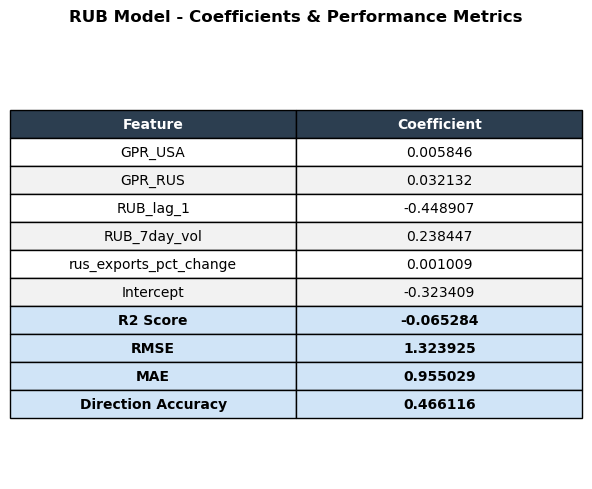

In [169]:
coef_df_rub = pd.DataFrame({
    'Feature': list(X_rub.columns) + ['Intercept'],
    'Coefficient': list(model_rub.coef_) + [model_rub.intercept_]
})

y_rub_pred = model_rub.predict(X_test)

metrics_df_rub = pd.DataFrame({
    'Feature': ['R2 Score', 'RMSE', 'MAE', 'Direction Accuracy'],
    'Coefficient': [
        r2_score(y_test, y_rub_pred),
        np.sqrt(mean_squared_error(y_test, y_rub_pred)),
        mean_absolute_error(y_test, y_rub_pred),
        np.mean(np.sign(y_rub_pred) == np.sign(y_test))
    ]
})

combined_df_rub = pd.concat([coef_df_rub, metrics_df_rub], ignore_index=True)

fig, ax = plt.subplots(figsize=(6, 5))
ax.axis('off')

table = ax.table(
    cellText=combined_df_rub.round(6).values,
    colLabels=combined_df_rub.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

for j in range(len(combined_df_rub.columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

n_coef_rub = len(coef_df_rub)
for i in range(1, n_coef_rub + 1):
    for j in range(len(combined_df_rub.columns)):
        table[i, j].set_facecolor('#f2f2f2' if i % 2 == 0 else 'white')

for i in range(n_coef_rub + 1, len(combined_df_rub) + 1):
    for j in range(len(combined_df_rub.columns)):
        table[i, j].set_facecolor('#d0e4f7')
        table[i, j].set_text_props(fontweight='bold')

plt.title('RUB Model - Coefficients & Performance Metrics',
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

The two linear regression models reveal interesting differences in how GPR and export growth relate to daily currency changes for USD and RUB. For the USD model, GPR_USA has a small positive effect (0.0035) while GPR_RUS is negatively associated (0.017), suggesting that rising US geopolitical risk is marginally associated with dollar strength while Russian risk slightly dampens it. The RUB model tells a more intuitive story where GPR_RUS has a positive coefficient (0.032) and GPR_USA also positive (0.0059), suggesting that elevated geopolitical risk from either country is associated with upward pressure on the ruble, possibly reflecting oil price dynamics that temporarily strengthen the currency even during tense periods. The lagged return variable is the strongest predictor in both models, with a stronger negative effect in the RUB model (0.449 vs 0.025 for USD), indicating that ruble movements are more subject to mean reversion than dollar movements. The 7-day rolling volatility has opposite signs across the two models, negatively associated with USD changes (0.046) but positively with RUB changes (0.239), which aligns with the broader finding in this analysis that RUB volatility behaves structurally differently from USD volatility. Export growth contributes very little to both models (0.0008 for USD, 0.0009 for RUB), confirming the limitation of using annual export data to explain daily currency movements.

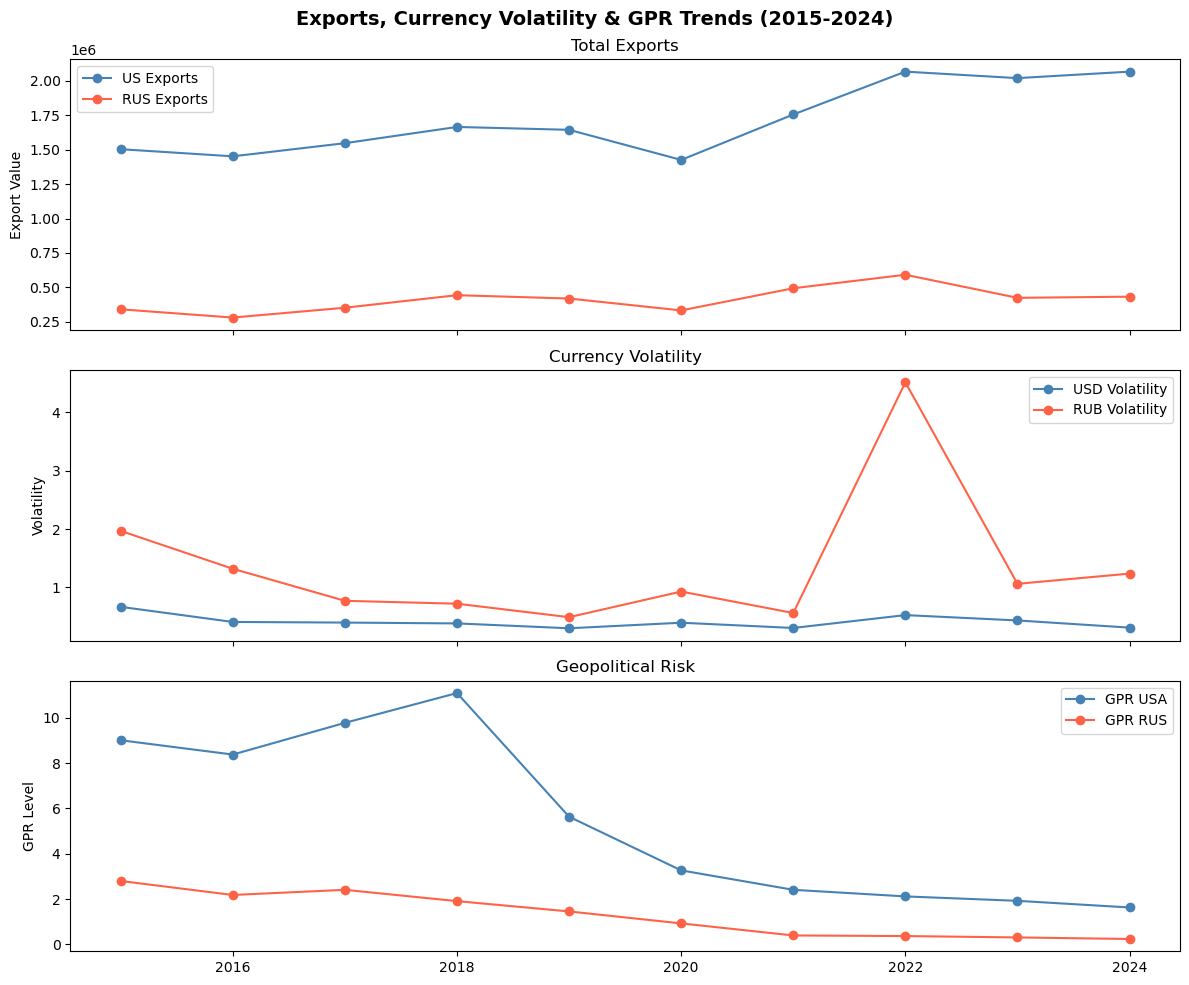

In [170]:
USDEUR_annual = USDEUR_clean.groupby('Year')['USD_7day_vol'].mean().reset_index()
USDEUR_annual.columns = ['Year', 'usd_volatility']

RUBEUR_annual = RUBEUR_clean.groupby('Year')['RUB_7day_vol'].mean().reset_index()
RUBEUR_annual.columns = ['Year', 'rub_volatility']

GPR_annual = GPR_data.copy()
GPR_annual['Year'] = pd.to_datetime(GPR_data['month']).dt.year
GPR_annual = GPR_annual.groupby('Year')[['GPR_USA', 'GPR_RUS']].mean().reset_index()

modeling_exports = US_exports[['Year', 'Value']].rename(columns={'Value': 'us_exports'})
modeling_exports = modeling_exports.merge(RUS_exports[['Year', 'Value']].rename(columns={'Value': 'rus_exports'}), on='Year')
modeling_exports = modeling_exports.merge(GPR_annual, on='Year')
modeling_exports = modeling_exports.merge(USDEUR_annual, on='Year')
modeling_exports = modeling_exports.merge(RUBEUR_annual, on='Year')
modeling_exports = modeling_exports.dropna()

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Exports, Currency Volatility & GPR Trends (2015-2024)', fontsize=14, fontweight='bold')

axes[0].plot(modeling_exports['Year'], modeling_exports['us_exports'], color='steelblue', marker='o', linewidth=1.5, label='US Exports')
axes[0].plot(modeling_exports['Year'], modeling_exports['rus_exports'], color='tomato', marker='o', linewidth=1.5, label='RUS Exports')
axes[0].set_ylabel('Export Value')
axes[0].set_title('Total Exports')
axes[0].legend()

axes[1].plot(modeling_exports['Year'], modeling_exports['usd_volatility'], color='steelblue', marker='o', linewidth=1.5, label='USD Volatility')
axes[1].plot(modeling_exports['Year'], modeling_exports['rub_volatility'], color='tomato', marker='o', linewidth=1.5, label='RUB Volatility')
axes[1].set_ylabel('Volatility')
axes[1].set_title('Currency Volatility')
axes[1].legend()

axes[2].plot(modeling_exports['Year'], modeling_exports['GPR_USA'], color='steelblue', marker='o', linewidth=1.5, label='GPR USA')
axes[2].plot(modeling_exports['Year'], modeling_exports['GPR_RUS'], color='tomato', marker='o', linewidth=1.5, label='GPR RUS')
axes[2].set_ylabel('GPR Level')
axes[2].set_title('Geopolitical Risk')
axes[2].legend()

plt.tight_layout()
plt.show()

The three panels reveal an interesting pattern in how exports, currency volatility, and geopolitical risk interact over the 2015 to 2024 period. For Russia, the most striking interaction occurs in 2022, where the sharp spike in RUB volatility (middle panel) coincides precisely with a drop in Russian exports (top panel), suggesting that currency instability directly disrupted trade flows rather than GPR driving both independently, since GPR RUS continues its steady decline in the bottom panel during the same period. For the US, the relationship is more muted but still visible, as the period of highest GPR USA (2015 to 2018) corresponds to relatively flat export growth, while the subsequent decline in GPR USA from 2019 onwards aligns with a stronger upward trend in US exports, hinting that lower geopolitical uncertainty may have supported trade expansion. USD volatility remains low and stable throughout, showing little co-movement with either US exports or GPR USA, which suggests the dollar is largely insulated from the kind of feedback loop between geopolitical risk, currency instability, and export disruption that is clearly visible for Russia. Overall the panels suggest that for Russia these three variables are tightly interconnected, while for the US they operate more independently of each other.

# Conclusions

The most fundamental finding of this analysis is that the US dollar and the Russian ruble are not simply two currencies operating at different scales. They represent two entirely different relationships between a country, its geopolitical environment, and its financial markets. The dollar behaves as a mature reserve currency that absorbs geopolitical noise without transmitting it into meaningful volatility, while the ruble functions as a highly reactive currency where external shocks, domestic policy uncertainty, and trade disruptions compound one another in ways that are difficult to predict and slow to resolve. This distinction was visible as early as 2015 and 2016, when the initial wave of Western sanctions following the Crimea annexation and the concurrent collapse in oil prices pushed RUB volatility to its highest levels in the early part of the dataset, while the dollar remained largely unaffected despite elevated US GPR driven by domestic political tensions. For commodity traders and macroeconomic strategists, this asymmetry is not merely an academic observation but a structural feature of the market that should inform how risk is allocated and monitored across currency exposures.

Geopolitical risk, as captured by the GPR index, proved to be a weaker direct driver of currency volatility than initially expected for both currencies. What the models consistently showed is that it is not geopolitical risk in isolation that moves markets, but rather the interaction between geopolitical stress and existing market turbulence. The period between 2017 and 2019, which included the peak of US GPR driven by trade war tensions with China and domestic political uncertainty under the Trump administration, produced surprisingly little USD volatility, confirming that elevated geopolitical risk scores do not automatically translate into financial market disruption when underlying economic conditions remain stable. When volatility is already elevated, geopolitical risk amplifies it further, but on its own, a high GPR reading does not reliably signal an extreme currency day. For traders with exposure to the ruble, this means that rolling volatility measures and momentum indicators should carry more weight in risk models than geopolitical risk scores, and that the interaction between the two is where the most actionable signal lies.

The export dimension of the analysis added important context to these currency dynamics. The COVID-19 shock of 2020 serves as a particularly clear illustration, as both US and Russian exports collapsed simultaneously and both fuel export curves converged at their lowest point, yet the currency impact was asymmetric, with the ruble absorbing a more severe depreciation while the dollar benefited from its safe haven status. For Russia, the tight negative relationship between a stronger ruble and lower agricultural exports confirms that currency strength directly undermines trade competitiveness in sectors outside of energy. Russia's fuel exports move largely in sync with global energy prices regardless of the exchange rate, reflecting the price-inelastic nature of energy demand and Russia's role as a supply-side actor rather than a price-taker. For trade ministry analysts on the Russian side, this represents a structural tension that requires active management, since currency appreciation driven by energy revenues directly undermines the competitiveness of non-energy exports, creating a classic resource curse dynamic. For the US, exports and the dollar tend to move together not because a strong dollar makes exports cheaper, but because both are simultaneously driven by the same underlying condition of a strong and growing economy, a dynamic that US strategists should be careful not to misread as evidence of export resilience.

Perhaps the most telling result is the behavior of both currencies around 2022. The full-scale Russian invasion of Ukraine in February 2022 produced the largest RUB volatility spike in the entire dataset, a sharp collapse in Russian exports as Western sanctions severed key trade relationships, and a dramatic depreciation of the ruble that took years to partially stabilize. Yet despite the severity of this shock, the GPR index for Russia continued its gradual downward trend rather than spiking sharply, exposing a fundamental limitation of the index in capturing sudden and structurally transformative geopolitical ruptures. The subsequent divergence in fuel export trajectories after 2022, with Russia dropping sharply while the US maintained elevated levels, reflects the long-term trade consequences of geopolitical isolation that currency models alone cannot fully capture. For the dollar, the same period produced barely a ripple, underscoring just how differently the two economies translate geopolitical reality into financial market behavior. For US strategists, this insulation can create blind spots, as the very stability of the dollar may lead to an underestimation of how severely geopolitical shocks propagate through more vulnerable currencies and the trade relationships that depend on them. Ultimately, this analysis reinforces that currency risk and geopolitical risk cannot be assessed in isolation from one another, and that the most robust strategies are those that account for how these forces interact rather than treating them as separate inputs.